# Prepare 2019 Sentinel-1 imagery

This notebook section retrieves and mosaics Sentinel-1A SAR imagery for the eastern
slopes of Heard Island. It can run from the beginning on a new machine with
the required Python packages and Copernicus Data Space OAuth credentials.

**Selected acquisitions:** April;
Sentinel-1A Stripmap, descending, single HH polarisation, relative orbit 4.

**Processing:** terrain-corrected gamma-nought, orthorectified with
Copernicus DEM 30 m, Lee 5 × 5 speckle filter. The output grid is
EPSG:32743 at 10 m pixel spacing. This is output sampling; it does not
imply that all source information has 10 m independent resolution.

The three output bands are HH backscatter in dB, radar shadow mask,
and data mask. Tiles are retained so a failed run can resume without
requesting successful tiles again.

In [ ]:
## Install the image segmentation package ##

# %pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.9 MB 2.2 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.9 MB 2.5 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/11.9 MB 2.8 MB/s eta 0:00:04
   --------- ------------------------------ 2.9/11.9 MB 2.9 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/11.9 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/11.9 MB 3.4 MB/s eta 0:00:03
   ------------------- -------------------- 5.8/11.9 MB 3.6 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/11.9 MB 3.8 MB/s eta 0:00:02
   -------------------------- ------------- 7.9/11.9 MB 3.9 MB/s eta 0:00:02
   ------------------------------ --------- 9.2/11.9 MB 4.1 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/11.9 MB 4.2 MB/s eta 0:00:01
   ---------

In [50]:
from getpass import getpass
from pathlib import Path
import os
import sys
from pystac_client import Client
import geopandas as gpd
import json
import zipfile
import shutil
from tempfile import TemporaryDirectory
from datetime import datetime, timezone

gdal_data = Path(sys.prefix) / "Library" / "share" / "gdal"

if (gdal_data / "gdalvrt.xsd").exists():
    os.environ["GDAL_DATA"] = str(gdal_data)

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import numpy as np
import requests

from math import ceil, floor
import rasterio
from rasterio.enums import Resampling
from rasterio.merge import merge
from rasterio.warp import transform_bounds, transform_geom
from rasterio.features import geometry_mask, rasterize, shapes
from rasterio.transform import from_bounds
from rasterio.vrt import WarpedVRT
from rasterio.windows import Window

from shapely.geometry import box, shape
from shapely.ops import unary_union

from scipy.ndimage import distance_transform_edt, label, median_filter, uniform_filter
from sklearn.ensemble import RandomForestClassifier

from scipy import ndimage as ndi
from shapely.geometry import shape as shapely_shape
from skimage.filters import sobel
from skimage.segmentation import watershed

In [ ]:
aoi_wgs84 = [73.45, -53.25, 73.85, -52.95]
pixel_size = 10
maximum_tile_pixels = 2400

aoi_utm = transform_bounds(
    "EPSG:4326", "EPSG:32743", *aoi_wgs84, densify_pts = 21)

min_x = int(np.floor(aoi_utm[0] / pixel_size) * pixel_size)
min_y = int(np.floor(aoi_utm[1] / pixel_size) * pixel_size)
max_x = int(np.ceil(aoi_utm[2] / pixel_size) * pixel_size)
max_y = int(np.ceil(aoi_utm[3] / pixel_size) * pixel_size)

full_width = (max_x - min_x) // pixel_size
full_height = (max_y - min_y) // pixel_size

if (full_width, full_height) != (2742, 3389):
    raise RuntimeError(
        f"Unexpected AOI grid: {full_width} × {full_height}")

tile_dir = Path("data/processed/sar_2019_tiles")
tile_dir.mkdir(parents = True, exist_ok = True)

tile_plan = []

for row_start in range(0, full_height, maximum_tile_pixels):
    for column_start in range(0, full_width, maximum_tile_pixels):
        tile_height = min(maximum_tile_pixels, full_height - row_start)
        tile_width = min(maximum_tile_pixels, full_width - column_start)

        tile_min_x = min_x + column_start * pixel_size
        tile_min_y = min_y + row_start * pixel_size
        tile_max_x = tile_min_x + tile_width * pixel_size
        tile_max_y = tile_min_y + tile_height * pixel_size

        tile_name = (
            f"S1A_2019-04-07_RTC_10m_"
            f"r{row_start}_c{column_start}.tif")

        tile_plan.append({
            "path": tile_dir / tile_name,
            "width": tile_width,
            "height": tile_height,
            "bbox": (
                tile_min_x, tile_min_y,
                tile_max_x, tile_max_y)})

print(f"Output grid: {full_width} × {full_height} pixels")
print(f"Planned Process API requests: {len(tile_plan)}")

for tile in tile_plan:
    print(tile["path"].name, tile["width"], "×", tile["height"])

Output grid: 2742 × 3389 pixels
Planned Process API requests: 4
S1A_2019-04-07_RTC_10m_r0_c0.tif 2400 × 2400
S1A_2019-04-07_RTC_10m_r0_c2400.tif 342 × 2400
S1A_2019-04-07_RTC_10m_r2400_c0.tif 2400 × 989
S1A_2019-04-07_RTC_10m_r2400_c2400.tif 342 × 989


In [8]:
missing_tiles = []

for tile in tile_plan:
    tile_path = tile["path"]

    if not tile_path.exists():
        missing_tiles.append(tile)
        continue

    try:
        with rasterio.open(tile_path) as source:
            actual_size = (source.width, source.height, source.count)
            expected_size = (tile["width"], tile["height"], 3)

            if actual_size != expected_size:
                raise ValueError(
                    f"Expected {expected_size}, found {actual_size}")

            if source.crs.to_epsg() != 32743:
                raise ValueError(f"Unexpected CRS: {source.crs}")

            if not np.allclose(source.res, (10, 10)):
                raise ValueError(f"Unexpected resolution: {source.res}")

            if not np.allclose(
                source.bounds, tile["bbox"], rtol = 0, atol = 0.01):
                raise ValueError("Tile bounds do not match the grid")

            source.read(1, window = ((0, 16), (0, 16)))
    except (rasterio.errors.RasterioIOError, ValueError) as error:
        raise RuntimeError(
            f"Existing tile needs attention: {tile_path}") from error

    print("Reusing:", tile_path.name)

print(f"Tiles to download: {len(missing_tiles)}")

Reusing: S1A_2019-04-07_RTC_10m_r0_c0.tif
Reusing: S1A_2019-04-07_RTC_10m_r0_c2400.tif
Reusing: S1A_2019-04-07_RTC_10m_r2400_c0.tif
Reusing: S1A_2019-04-07_RTC_10m_r2400_c2400.tif
Tiles to download: 0


C:\Users\harry\AppData\Local\Temp\ipykernel_14664\2332477683.py:29: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 16), (0, 16)))


In [9]:
evalscript = """
//VERSION=3

function setup() {
    return {
        input: ["HH", "shadowMask", "dataMask"],
        output: {
            id: "default",
            bands: 3,
            sampleType: "FLOAT32"
        }
    }
}

function evaluatePixel(sample) {
    let hhDb = sample.HH > 0
        ? 10 * Math.log(sample.HH) / Math.LN10
        : -99;

    return [hhDb, sample.shadowMask, sample.dataMask];
}
"""

if missing_tiles:
    client_id = getpass("Copernicus client ID: ").strip()
    client_secret = getpass("Copernicus client secret: ").strip()

    if not client_id or not client_secret:
        raise ValueError("Both OAuth credentials are required")

    token_url = (
        "https://identity.dataspace.copernicus.eu/auth/realms/"
        "CDSE/protocol/openid-connect/token")

    token_response = requests.post(
        token_url,
        data = {
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret},
        timeout = (30, 30))

    del client_id, client_secret

    if not token_response.ok:
        raise RuntimeError(
            f"Authentication failed ({token_response.status_code}): "
            f"{token_response.text[:300]}")

    access_token = token_response.json()["access_token"]

    for tile in missing_tiles:
        request_body = {
            "input": {
                "bounds": {
                    "bbox": list(tile["bbox"]),
                    "properties": {
                        "crs": (
                            "http://www.opengis.net/def/crs/"
                            "EPSG/0/32743")}},
                "data": [{
                    "type": "sentinel-1-grd",
                    "dataFilter": {
                        "timeRange": {
                            "from": "2019-04-07T00:00:00Z",
                            "to": "2019-04-07T00:02:00Z"},
                        "acquisitionMode": "SM",
                        "polarization": "SH",
                        "orbitDirection": "DESCENDING",
                        "resolution": "HIGH"},
                    "processing": {
                        "backCoeff": "GAMMA0_TERRAIN",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS_30",
                        "radiometricTerrainOversampling": 3,
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 5,
                            "windowSizeY": 5}}}]},
            "output": {
                "width": tile["width"],
                "height": tile["height"],
                "responses": [{
                    "identifier": "default",
                    "format": {"type": "image/tiff"}}]},
            "evalscript": evalscript}

        print("Requesting:", tile["path"].name, flush = True)

        response = requests.post(
            "https://sh.dataspace.copernicus.eu/process/v1",
            headers = {
                "Authorization": f"Bearer {access_token}",
                "Accept": "image/tiff"},
            json = request_body,
            timeout = (30, 300))

        if not response.ok:
            raise RuntimeError(
                f"Tile request failed ({response.status_code}): "
                f"{response.text[:1000]}")

        temporary_path = tile["path"].with_suffix(".partial.tif")
        temporary_path.write_bytes(response.content)

        with rasterio.open(temporary_path) as source:
            actual_size = (source.width, source.height, source.count)
            expected_size = (tile["width"], tile["height"], 3)

            if actual_size != expected_size:
                raise ValueError(
                    f"{temporary_path.name}: expected {expected_size}, "
                    f"found {actual_size}")

            if source.crs.to_epsg() != 32743:
                raise ValueError(
                    f"{temporary_path.name}: unexpected CRS")

            if not np.allclose(
                source.bounds, tile["bbox"], rtol = 0, atol = 0.01):
                raise ValueError(
                    f"{temporary_path.name}: unexpected bounds")

            source.read(1, window = ((0, 16), (0, 16)))

        temporary_path.replace(tile["path"])
        print("Downloaded:", tile["path"].name)

    del access_token
else:
    print("All four tiles are present; no authentication or API requests.")

All four tiles are present; no authentication or API requests.


In [10]:
tile_paths = [tile["path"] for tile in tile_plan]
output_path = Path("data/processed/S1A_HH_2019-04-07_RTC_10m.tif")
temporary_output = output_path.with_name(
    f"{output_path.stem}_building.tif")

temporary_output.unlink(missing_ok = True)

print("Writing mosaic in chunks...", flush = True)

merge(
    tile_paths,
    dst_path = temporary_output,
    mem_limit = 64,
    dst_kwds = {
        "compress": "deflate",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "BIGTIFF": "IF_SAFER"})

with rasterio.open(temporary_output, "r+") as mosaic:
    shape = (mosaic.count, mosaic.height, mosaic.width)

    if shape != (3, full_height, full_width):
        raise RuntimeError(f"Unexpected mosaic shape: {shape}")

    if mosaic.crs.to_epsg() != 32743:
        raise RuntimeError(f"Unexpected CRS: {mosaic.crs}")

    if not np.allclose(
        mosaic.bounds, (min_x, min_y, max_x, max_y),
        rtol = 0, atol = 0.01):
        raise RuntimeError("Mosaic bounds do not match the planned grid")

    mosaic.set_band_description(1, "HH backscatter (dB)")
    mosaic.set_band_description(2, "Radar shadow mask")
    mosaic.set_band_description(3, "Data mask")

    print("Shape:", shape)
    print("Resolution:", mosaic.res)
    print("Internal blocks:", mosaic.block_shapes[0])

os.replace(temporary_output, output_path)
print("Completed:", output_path)

Writing mosaic in chunks...
Shape: (3, 3389, 2742)
Resolution: (10.0, 10.0)
Internal blocks: (256, 256)
Completed: data\processed\S1A_HH_2019-04-07_RTC_10m.tif


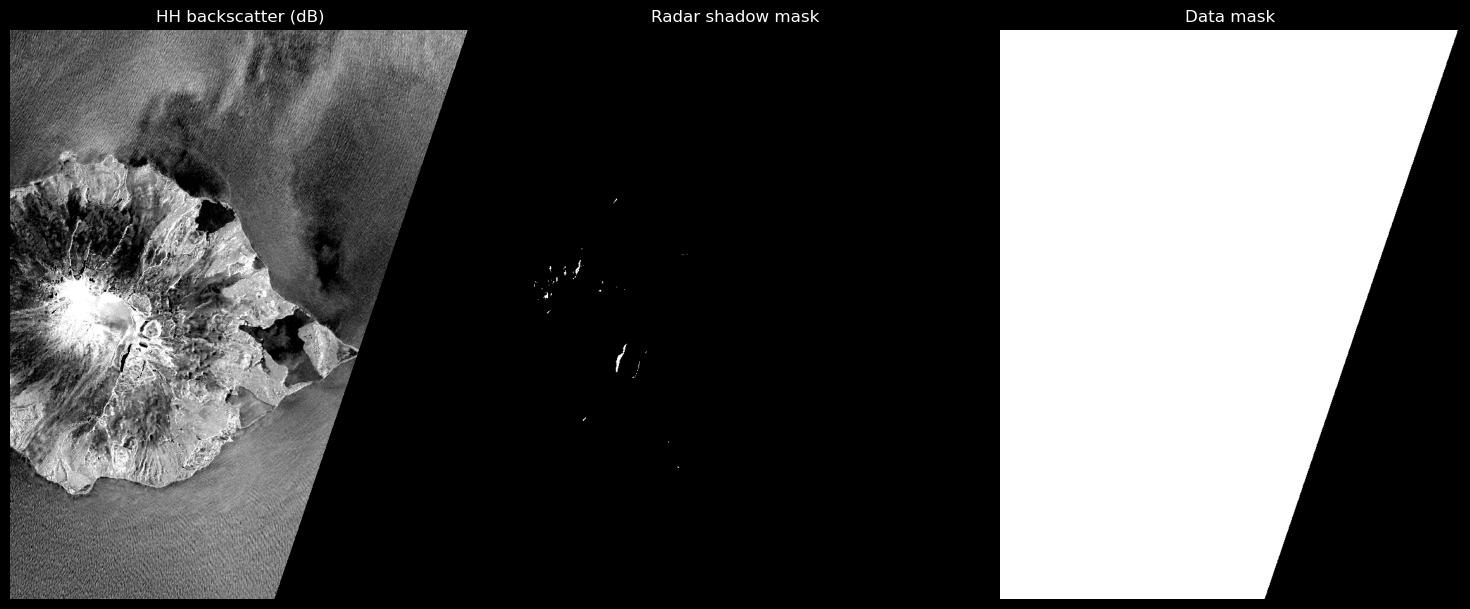

Unshadowed valid preview pixels: 78.3%


In [11]:
with rasterio.open(output_path) as source:
    preview_height = min(900, source.height)
    preview_width = round(
        source.width * preview_height / source.height)

    preview = source.read(
        out_shape = (3, preview_height, preview_width),
        resampling = Resampling.nearest)

hh_db, shadow_mask, data_mask = preview

valid = (
    (data_mask > 0.5)
    & (shadow_mask < 0.5)
    & (hh_db > -99)
    & np.isfinite(hh_db))

if not np.any(valid):
    raise RuntimeError("No unshadowed valid pixels in the preview")

lower, upper = np.percentile(hh_db[valid], [2, 98])

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 3, figsize = (15, 6))

    axes[0].imshow(
        np.ma.masked_where(~valid, hh_db),
        cmap = "gray", vmin = lower, vmax = upper)
    axes[0].set_title("HH backscatter (dB)")

    axes[1].imshow(
        shadow_mask, cmap = "gray", vmin = 0, vmax = 1)
    axes[1].set_title("Radar shadow mask")

    axes[2].imshow(
        data_mask, cmap = "gray", vmin = 0, vmax = 1)
    axes[2].set_title("Data mask")

    for ax in axes:
        ax.axis("off")

    fig.tight_layout()
    plt.show()

print(f"Unshadowed valid preview pixels: {valid.mean():.1%}")

In [12]:
heard_bounds = (73.2, -53.2, 73.9667, -52.9333)
grid_width, grid_height = 750, 300

catalog = Client.open("https://stac.dataspace.copernicus.eu/v1/")

search = catalog.search(
    collections = ["sentinel-1-grd"],
    bbox = heard_bounds,
    datetime = "2019-04-06T00:00:00Z/2019-04-06T23:59:59Z",
    method = "GET",
    limit = 10,
    max_items = 20)

iw_items = [
    item for item in search.items()
    if item.id.startswith("S1A_IW_") and "_1SSH_" in item.id]

if not iw_items:
    raise RuntimeError("No 6 April 2019 IW HH scene found")

grid_transform = from_bounds(
    *heard_bounds, grid_width, grid_height)

for item in iw_items:
    footprint = geometry_mask(
        [item.geometry],
        out_shape = (grid_height, grid_width),
        transform = grid_transform,
        invert = True)

    print(item.id)
    print(f"Coverage of map rectangle: {footprint.mean():.1%}")


S1A_IW_GRDH_1SSH_20190406T142730_20190406T142755_026670_02FE32_F3EE_COG
Coverage of map rectangle: 92.4%
S1A_IW_GRDH_1SSH_20190406T142730_20190406T142755_026670_02FE32_B6A4_COG
Coverage of map rectangle: 92.4%


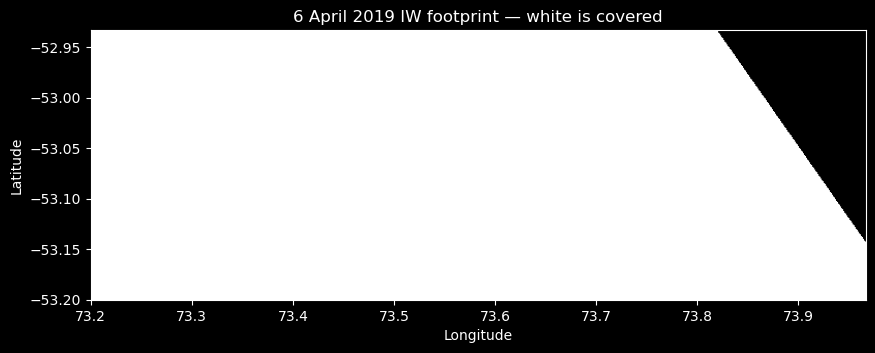

In [13]:
## Plot the 2019 IW footprint

# Matplotlib expects west, east, south, north.
plot_extent = (
    heard_bounds[0], heard_bounds[2],
    heard_bounds[1], heard_bounds[3])

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize = (10, 5))
    ax.imshow(
        footprint,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    ax.set(
        title = "6 April 2019 IW footprint — white is covered",
        xlabel = "Longitude",
        ylabel = "Latitude")
    plt.show()

In [14]:
## Rank full-island Sentinel-1 footprints

# Compare acquisition footprints without downloading imagery.
periods = {
    "2019": "2019-03-01/2019-04-30",
    "2026": "2026-03-01/2026-04-30"}

for year, date_range in periods.items():
    search = catalog.search(
        collections = ["sentinel-1-grd"],
        bbox = heard_bounds,
        datetime = date_range,
        method = "GET",
        limit = 50,
        max_items = 100)

    candidates = []
    seen = set()

    for item in search.items():
        # Collapse duplicate COGs of the same acquisition and footprint.
        key = (
            item.datetime,
            item.properties.get("sar:instrument_mode"),
            tuple(item.properties.get("sar:polarizations", [])),
            tuple(item.bbox))

        if key in seen:
            continue

        seen.add(key)

        footprint = geometry_mask(
            [item.geometry],
            out_shape = (grid_height, grid_width),
            transform = grid_transform,
            invert = True)

        candidates.append((footprint.mean(), item))

    print(f"\n{year}: {len(candidates)} distinct footprints")

    for coverage, item in sorted(candidates, reverse = True, key = lambda row: row[0])[:10]:
        mode = item.properties.get("sar:instrument_mode")
        pol = item.properties.get("sar:polarizations")
        orbit = item.properties.get("sat:relative_orbit")

        print(
            f"{coverage:.1%}  {item.datetime:%Y-%m-%d %H:%M}  "
            f"{mode}  {pol}  orbit {orbit}  {item.id}")


2019: 26 distinct footprints
100.0%  2019-04-25 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190425T141918_20190425T141947_026947_030845_057E_COG
100.0%  2019-04-13 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190413T141917_20190413T141946_026772_0301F3_1036_COG
100.0%  2019-04-01 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190401T141917_20190401T141946_026597_02FB8B_DA6E_COG
100.0%  2019-03-20 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190320T141916_20190320T141945_026422_02F516_81F5_COG
100.0%  2019-03-08 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190308T141916_20190308T141945_026247_02EEA3_EDE4_COG
92.8%  2019-03-13 14:27  IW  ['HH']  orbit 173  S1A_IW_GRDH_1SSH_20190313T142729_20190313T142754_026320_02F14B_9B72_COG
92.8%  2019-03-13 14:27  IW  ['HH']  orbit 173  S1A_IW_GRDH_1SSH_20190313T142729_20190313T142754_026320_02F14B_98BA_COG
92.7%  2019-03-01 14:27  IW  ['HH']  orbit 173  S1A_IW_GRDH_1SSH_20190301T142729_20190301T142754_026145_02EAE9_1DE6_COG
92.7%

In [15]:
## Set the matched full-island SAR grid

# Both scenes use IW, HH, ascending orbit 100.
scene_dates = {
    2019: "2019-04-13",
    2026: "2026-04-12"}

# Include a margin around the AAD Heard Island map extent.
full_aoi_wgs84 = (73.18, -53.22, 73.99, -52.91)
pixel_size = 10
maximum_tile_pixels = 2400

min_x, min_y, max_x, max_y = transform_bounds(
    "EPSG:4326",
    "EPSG:32743",
    *full_aoi_wgs84,
    densify_pts = 21)

min_x = floor(min_x / pixel_size) * pixel_size
min_y = floor(min_y / pixel_size) * pixel_size
max_x = ceil(max_x / pixel_size) * pixel_size
max_y = ceil(max_y / pixel_size) * pixel_size

full_width = int((max_x - min_x) / pixel_size)
full_height = int((max_y - min_y) / pixel_size)

tile_count = (
    ceil(full_width / maximum_tile_pixels)
    * ceil(full_height / maximum_tile_pixels))

print("Scenes:", scene_dates)
print(f"Full-island grid: {full_width} × {full_height} pixels")
print(f"Tiles per scene: {tile_count}")

Scenes: {2019: '2019-04-13', 2026: '2026-04-12'}
Full-island grid: 5496 × 3557 pixels
Tiles per scene: 6


In [18]:
## Download full-island 2019 IW tiles

scene_date = scene_dates[2019]
tile_dir = Path("data/processed/sar_2019_iw_tiles")
tile_dir.mkdir(parents = True, exist_ok = True)

# Keep the same three bands as the Stripmap trial.
evalscript = """
//VERSION=3

function setup() {
    return {
        input: ["HH", "shadowMask", "dataMask"],
        output: {
            id: "default",
            bands: 3,
            sampleType: "FLOAT32"
        }
    }
}

function evaluatePixel(sample) {
    let hhDb = sample.HH > 0
        ? 10 * Math.log(sample.HH) / Math.LN10
        : -99;

    return [hhDb, sample.shadowMask, sample.dataMask];
}
"""

def valid_tile(path, width, height):
    if not path.exists() or path.stat().st_size < 1024:
        return False

    try:
        with rasterio.open(path) as source:
            if (
                source.width != width
                or source.height != height
                or source.count != 3
                or source.crs.to_epsg() != 32743
            ):
                return False

            source.read(1, window = ((0, 1), (0, 1)))
            return True
    except (rasterio.errors.RasterioIOError, OSError):
        return False

# Prepare the six tile bounds on the shared 10 m grid.
tile_specs = []

for row_start in range(0, full_height, maximum_tile_pixels):
    for column_start in range(0, full_width, maximum_tile_pixels):
        tile_height = min(
            maximum_tile_pixels, full_height - row_start)
        tile_width = min(
            maximum_tile_pixels, full_width - column_start)

        tile_min_x = min_x + column_start * pixel_size
        tile_min_y = min_y + row_start * pixel_size

        tile_bounds = [
            tile_min_x,
            tile_min_y,
            tile_min_x + tile_width * pixel_size,
            tile_min_y + tile_height * pixel_size]

        tile_path = tile_dir / (
            f"S1A_IW_HH_{scene_date}_RTC_10m_"
            f"r{row_start}_c{column_start}.tif")

        tile_specs.append((
            tile_path, tile_width, tile_height, tile_bounds))

missing_tiles = [
    spec for spec in tile_specs
    if not valid_tile(spec[0], spec[1], spec[2])]

print(f"Valid tiles: {len(tile_specs) - len(missing_tiles)} of {len(tile_specs)}")
print(f"Tiles to download: {len(missing_tiles)}")

if missing_tiles:
    # Credentials are requested only when a download is needed.
    client_id = getpass("Copernicus client ID: ").strip()
    client_secret = getpass("Copernicus client secret: ").strip()

    if not client_id or not client_secret:
        raise ValueError("Both credentials are required")

    token_response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/"
        "realms/CDSE/protocol/openid-connect/token",
        data = {
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret},
        timeout = 30)

    if not token_response.ok:
        raise RuntimeError(
            f"Authentication failed ({token_response.status_code}): "
            f"{token_response.text[:300]}")

    access_token = token_response.json()["access_token"]
    del client_secret

    for tile_path, tile_width, tile_height, tile_bounds in missing_tiles:
        request_body = {
            "input": {
                "bounds": {
                    "bbox": tile_bounds,
                    "properties": {
                        "crs": (
                            "http://www.opengis.net/def/crs/"
                            "EPSG/0/32743")}},
                "data": [{
                    "type": "sentinel-1-grd",
                    "dataFilter": {
                        "timeRange": {
                            "from": f"{scene_date}T14:19:00Z",
                            "to": f"{scene_date}T14:20:00Z"},
                        "acquisitionMode": "IW",
                        "polarization": "SH",
                        "orbitDirection": "ASCENDING",
                        "resolution": "HIGH"},
                    "processing": {
                        "backCoeff": "GAMMA0_TERRAIN",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS_30",
                        "radiometricTerrainOversampling": 3,
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 5,
                            "windowSizeY": 5}}}]},
            "output": {
                "width": tile_width,
                "height": tile_height,
                "responses": [{
                    "identifier": "default",
                    "format": {
                        "type": "image/tiff"}}]},
            "evalscript": evalscript}

        # Write to a temporary TIFF so an interrupted download
        # cannot masquerade as a completed tile.
        temporary_tile = tile_path.with_name(
            f"{tile_path.stem}_building.tif")
        temporary_tile.unlink(missing_ok = True)

        print("Downloading:", tile_path.name, flush = True)

        with requests.post(
            "https://sh.dataspace.copernicus.eu/process/v1",
            headers = {
                "Authorization": f"Bearer {access_token}",
                "Content-Type": "application/json",
                "Accept": "image/tiff"},
            json = request_body,
            stream = True,
            timeout = (30, 300)) as response:

            if not response.ok:
                raise RuntimeError(
                    f"Tile failed ({response.status_code}): "
                    f"{response.text[:500]}")

            with temporary_tile.open("wb") as output:
                for chunk in response.iter_content(
                    chunk_size = 1024 * 1024
                ):
                    if chunk:
                        output.write(chunk)

        if not valid_tile(
            temporary_tile, tile_width, tile_height
        ):
            raise RuntimeError(
                f"Downloaded tile failed validation: {tile_path.name}")

        temporary_tile.replace(tile_path)
        print("Saved:", tile_path.name, flush = True)

print("Valid final tiles:", sum(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs))

Valid tiles: 0 of 6
Tiles to download: 6
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r0_c0.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r0_c0.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r0_c2400.tif


C:\Users\harry\AppData\Local\Temp\ipykernel_41064\3362925263.py:45: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 1), (0, 1)))


Saved: S1A_IW_HH_2019-04-13_RTC_10m_r0_c2400.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r0_c4800.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r0_c4800.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c0.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c0.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c2400.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c2400.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c4800.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c4800.tif
Valid final tiles: 6


In [16]:
## Mosaic the full-island 2019 IW tiles

# Check the six inputs before writing a new mosaic.
tile_paths = [spec[0] for spec in tile_specs]

if not all(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs
):
    raise RuntimeError("One or more 2019 IW tiles are missing or invalid")

output_path = Path(
    "data/processed/S1A_IW_HH_2019-04-13_RTC_10m.tif")
temporary_output = output_path.with_name(
    f"{output_path.stem}_building.tif")

# A previous interrupted mosaic may have left a damaged TIFF.
temporary_output.unlink(missing_ok = True)

print("Writing full-island mosaic in chunks...", flush = True)

merge(
    tile_paths,
    dst_path = temporary_output,
    mem_limit = 64,
    dst_kwds = {
        "driver": "GTiff",
        "compress": "deflate",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "BIGTIFF": "IF_SAFER"})

with rasterio.open(temporary_output, "r+") as mosaic:
    shape = (mosaic.count, mosaic.height, mosaic.width)

    if shape != (3, full_height, full_width):
        raise RuntimeError(f"Unexpected mosaic shape: {shape}")

    mosaic.set_band_description(1, "HH backscatter (dB)")
    mosaic.set_band_description(2, "Radar shadow mask")
    mosaic.set_band_description(3, "Data mask")

temporary_output.replace(output_path)

print("Saved:", output_path)
print("Shape:", shape)

NameError: name 'tile_specs' is not defined

Valid data in AOI: 78.4%
Radar shadow within valid data: 0.1%


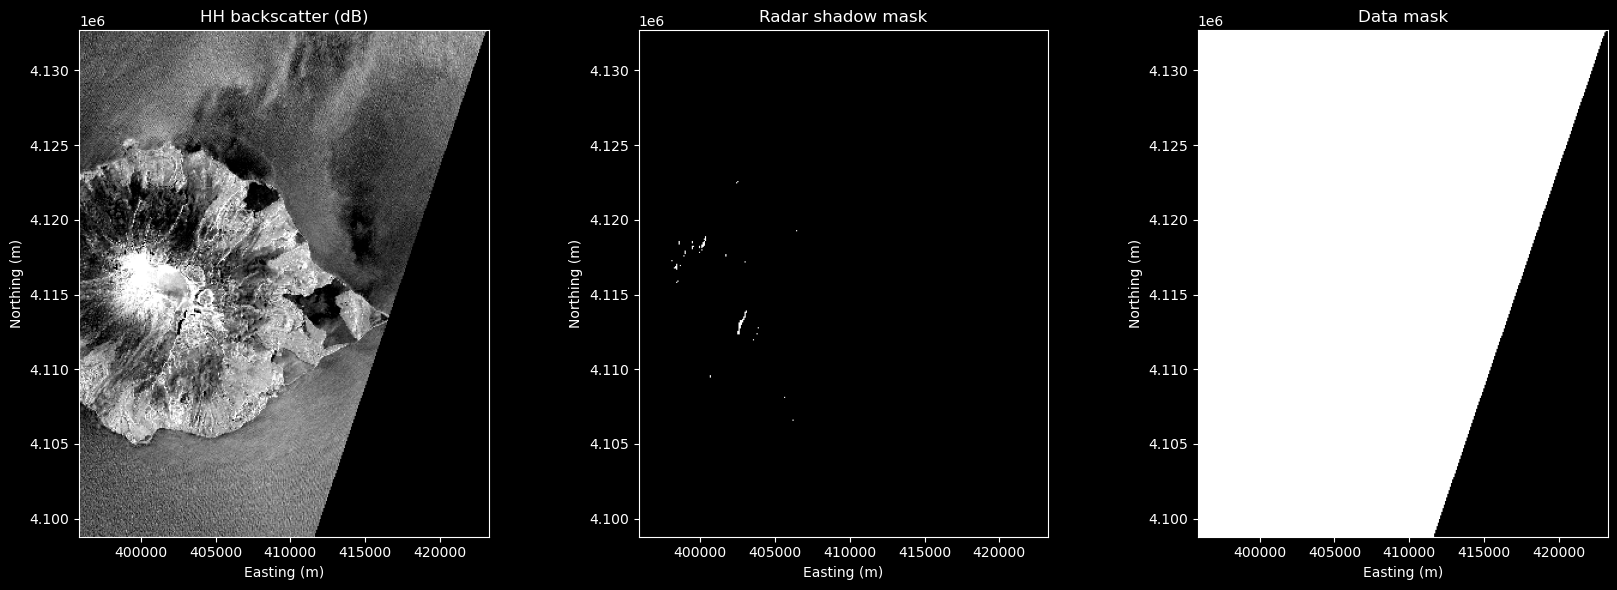

In [17]:
## Preview the full-island 2019 IW mosaic

# Read a reduced preview rather than the full raster into memory.
with rasterio.open(output_path) as source:
    preview_height = max(1, source.height // 8)
    preview_width = max(1, source.width // 8)

    preview = source.read(
        out_shape = (3, preview_height, preview_width))

    plot_extent = (
        source.bounds.left,
        source.bounds.right,
        source.bounds.bottom,
        source.bounds.top)

hh, shadow, data = preview
valid = data > 0.5

if not valid.any():
    raise RuntimeError("The mosaic contains no valid data")

hh_values = hh[valid & np.isfinite(hh) & (hh > -90)]
vmin, vmax = np.percentile(hh_values, [2, 98])

print(f"Valid data in AOI: {valid.mean():.1%}")
print(f"Radar shadow within valid data: {(shadow[valid] > 0.5).mean():.1%}")

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 3, figsize = (17, 6))

    axes[0].imshow(
        np.ma.masked_where(~valid, hh),
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = vmin,
        vmax = vmax)
    axes[0].set_title("HH backscatter (dB)")

    axes[1].imshow(
        shadow,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[1].set_title("Radar shadow mask")

    axes[2].imshow(
        valid,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[2].set_title("Data mask")

    for ax in axes:
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    fig.tight_layout()
    plt.show()

## 2026 

In [21]:
## Download full-island 2026 IW tiles

scene_date = scene_dates[2026]
tile_dir = Path("data/processed/sar_2026_iw_tiles")
tile_dir.mkdir(parents = True, exist_ok = True)

# Keep the same three bands as the Stripmap trial.
evalscript = """
//VERSION=3

function setup() {
    return {
        input: ["HH", "shadowMask", "dataMask"],
        output: {
            id: "default",
            bands: 3,
            sampleType: "FLOAT32"
        }
    }
}

function evaluatePixel(sample) {
    let hhDb = sample.HH > 0
        ? 10 * Math.log(sample.HH) / Math.LN10
        : -99;

    return [hhDb, sample.shadowMask, sample.dataMask];
}
"""

def valid_tile(path, width, height):
    if not path.exists() or path.stat().st_size < 1024:
        return False

    try:
        with rasterio.open(path) as source:
            if (
                source.width != width
                or source.height != height
                or source.count != 3
                or source.crs.to_epsg() != 32743
            ):
                return False

            source.read(1, window = ((0, 1), (0, 1)))
            return True
    except (rasterio.errors.RasterioIOError, OSError):
        return False

# Prepare the six tile bounds on the shared 10 m grid.
tile_specs = []

for row_start in range(0, full_height, maximum_tile_pixels):
    for column_start in range(0, full_width, maximum_tile_pixels):
        tile_height = min(
            maximum_tile_pixels, full_height - row_start)
        tile_width = min(
            maximum_tile_pixels, full_width - column_start)

        tile_min_x = min_x + column_start * pixel_size
        tile_min_y = min_y + row_start * pixel_size

        tile_bounds = [
            tile_min_x,
            tile_min_y,
            tile_min_x + tile_width * pixel_size,
            tile_min_y + tile_height * pixel_size]

        tile_path = tile_dir / (
            f"S1A_IW_HH_{scene_date}_RTC_10m_"
            f"r{row_start}_c{column_start}.tif")

        tile_specs.append((
            tile_path, tile_width, tile_height, tile_bounds))

missing_tiles = [
    spec for spec in tile_specs
    if not valid_tile(spec[0], spec[1], spec[2])]

print(f"Valid tiles: {len(tile_specs) - len(missing_tiles)} of {len(tile_specs)}")
print(f"Tiles to download: {len(missing_tiles)}")

if missing_tiles:
    # Credentials are requested only when a download is needed.
    client_id = getpass("Copernicus client ID: ").strip()
    client_secret = getpass("Copernicus client secret: ").strip()

    if not client_id or not client_secret:
        raise ValueError("Both credentials are required")

    token_response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/"
        "realms/CDSE/protocol/openid-connect/token",
        data = {
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret},
        timeout = 30)

    if not token_response.ok:
        raise RuntimeError(
            f"Authentication failed ({token_response.status_code}): "
            f"{token_response.text[:300]}")

    access_token = token_response.json()["access_token"]
    del client_secret

    for tile_path, tile_width, tile_height, tile_bounds in missing_tiles:
        request_body = {
            "input": {
                "bounds": {
                    "bbox": tile_bounds,
                    "properties": {
                        "crs": (
                            "http://www.opengis.net/def/crs/"
                            "EPSG/0/32743")}},
                "data": [{
                    "type": "sentinel-1-grd",
                    "dataFilter": {
                        "timeRange": {
                            "from": f"{scene_date}T14:19:00Z",
                            "to": f"{scene_date}T14:20:00Z"},
                        "acquisitionMode": "IW",
                        "polarization": "SH",
                        "orbitDirection": "ASCENDING",
                        "resolution": "HIGH"},
                    "processing": {
                        "backCoeff": "GAMMA0_TERRAIN",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS_30",
                        "radiometricTerrainOversampling": 3,
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 5,
                            "windowSizeY": 5}}}]},
            "output": {
                "width": tile_width,
                "height": tile_height,
                "responses": [{
                    "identifier": "default",
                    "format": {
                        "type": "image/tiff"}}]},
            "evalscript": evalscript}

        # Write to a temporary TIFF so an interrupted download
        # cannot masquerade as a completed tile.
        temporary_tile = tile_path.with_name(
            f"{tile_path.stem}_building.tif")
        temporary_tile.unlink(missing_ok = True)

        print("Downloading:", tile_path.name, flush = True)

        with requests.post(
            "https://sh.dataspace.copernicus.eu/process/v1",
            headers = {
                "Authorization": f"Bearer {access_token}",
                "Content-Type": "application/json",
                "Accept": "image/tiff"},
            json = request_body,
            stream = True,
            timeout = (30, 300)) as response:

            if not response.ok:
                raise RuntimeError(
                    f"Tile failed ({response.status_code}): "
                    f"{response.text[:500]}")

            with temporary_tile.open("wb") as output:
                for chunk in response.iter_content(
                    chunk_size = 1024 * 1024
                ):
                    if chunk:
                        output.write(chunk)

        if not valid_tile(
            temporary_tile, tile_width, tile_height
        ):
            raise RuntimeError(
                f"Downloaded tile failed validation: {tile_path.name}")

        temporary_tile.replace(tile_path)
        print("Saved:", tile_path.name, flush = True)

print("Valid final tiles:", sum(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs))

Valid tiles: 0 of 6
Tiles to download: 6
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r0_c0.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r0_c0.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r0_c2400.tif


C:\Users\harry\AppData\Local\Temp\ipykernel_41064\2390828930.py:45: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 1), (0, 1)))


Saved: S1A_IW_HH_2026-04-12_RTC_10m_r0_c2400.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r0_c4800.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r0_c4800.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c0.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c0.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c2400.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c2400.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c4800.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c4800.tif
Valid final tiles: 6


In [18]:
## Mosaic the full-island 2026 IW tiles

# Check the six inputs before writing a new mosaic.
tile_paths = [spec[0] for spec in tile_specs]

if not all(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs
):
    raise RuntimeError("One or more 2026 IW tiles are missing or invalid")

output_path = Path(
    "data/processed/S1A_IW_HH_2026-04-12_RTC_10m.tif")
temporary_output = output_path.with_name(
    f"{output_path.stem}_building.tif")

# A previous interrupted mosaic may have left a damaged TIFF.
temporary_output.unlink(missing_ok = True)

print("Writing full-island mosaic in chunks...", flush = True)

merge(
    tile_paths,
    dst_path = temporary_output,
    mem_limit = 64,
    dst_kwds = {
        "driver": "GTiff",
        "compress": "deflate",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "BIGTIFF": "IF_SAFER"})

with rasterio.open(temporary_output, "r+") as mosaic:
    shape = (mosaic.count, mosaic.height, mosaic.width)

    if shape != (3, full_height, full_width):
        raise RuntimeError(f"Unexpected mosaic shape: {shape}")

    mosaic.set_band_description(1, "HH backscatter (dB)")
    mosaic.set_band_description(2, "Radar shadow mask")
    mosaic.set_band_description(3, "Data mask")

temporary_output.replace(output_path)

print("Saved:", output_path)
print("Shape:", shape)

NameError: name 'tile_specs' is not defined

Valid data in AOI: 78.4%
Radar shadow within valid data: 0.1%


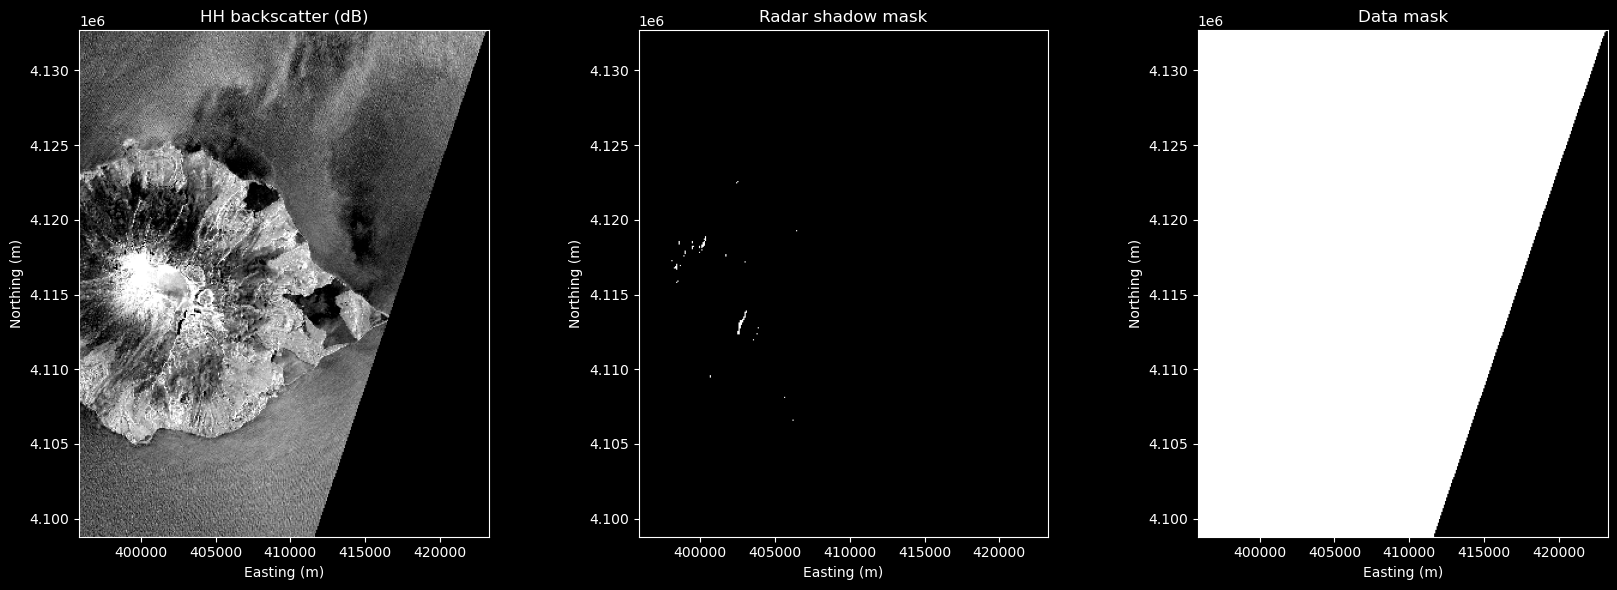

In [19]:
## Preview the full-island 2026 IW mosaic

# Read a reduced preview rather than the full raster into memory.

with rasterio.open(output_path) as source:
    preview_height = max(1, source.height // 8)
    preview_width = max(1, source.width // 8)

    preview = source.read(
        out_shape = (3, preview_height, preview_width))

    plot_extent = (
        source.bounds.left,
        source.bounds.right,
        source.bounds.bottom,
        source.bounds.top)

hh, shadow, data = preview
valid = data > 0.5

if not valid.any():
    raise RuntimeError("The mosaic contains no valid data")

hh_values = hh[valid & np.isfinite(hh) & (hh > -90)]
vmin, vmax = np.percentile(hh_values, [2, 98])

print(f"Valid data in AOI: {valid.mean():.1%}")
print(f"Radar shadow within valid data: {(shadow[valid] > 0.5).mean():.1%}")

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 3, figsize = (17, 6))

    axes[0].imshow(
        np.ma.masked_where(~valid, hh),
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = vmin,
        vmax = vmax)
    axes[0].set_title("HH backscatter (dB)")

    axes[1].imshow(
        shadow,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[1].set_title("Radar shadow mask")

    axes[2].imshow(
        valid,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[2].set_title("Data mask")

    for ax in axes:
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    fig.tight_layout()
    plt.show()

C:\Users\harry\AppData\Local\Temp\ipykernel_14664\2383942518.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hh = source.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\2383942518.py:39: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data_mask = source.read(


2019: 5496 × 3557 pixels, 99.9% valid preview pixels
2026: 5496 × 3557 pixels, 99.9% valid preview pixels
Matching grid: EPSG:32743
Shared HH display range: -36.0 to -3.2 dB


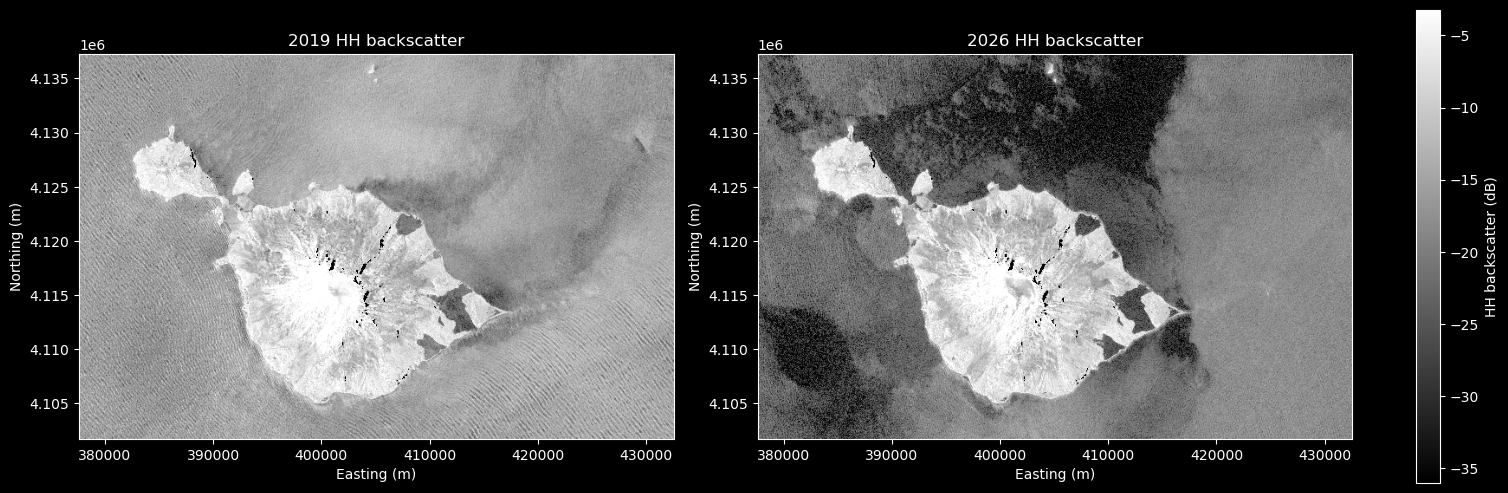

In [20]:
## Check the grids and compare both years on one brightness scale

# Use explicit paths so this cell does not depend on output_path.
mosaic_paths = {
    2019: Path("data/processed/S1A_IW_HH_2019-04-13_RTC_10m.tif"),
    2026: Path("data/processed/S1A_IW_HH_2026-04-12_RTC_10m.tif")}

previews = {}
reference_grid = None

for year, path in mosaic_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {year} mosaic: {path}")

    with rasterio.open(path) as source:
        if source.count != 3:
            raise ValueError(f"{year} mosaic has {source.count} bands; expected 3")

        grid = (
            source.crs,
            source.transform,
            source.width,
            source.height)

        if reference_grid is None:
            reference_grid = grid
            bounds = source.bounds
        elif grid != reference_grid:
            raise ValueError(f"{year} mosaic does not match the 2019 grid")

        # Read a small preview to keep memory use low.
        preview_height = max(1, source.height // 8)
        preview_width = max(1, source.width // 8)

        hh = source.read(
            1,
            out_shape = (preview_height, preview_width))

        data_mask = source.read(
            3,
            out_shape = (preview_height, preview_width))

        valid = (
            (data_mask > 0.5) &
            np.isfinite(hh) &
            (hh > -90))

        if not valid.any():
            raise ValueError(f"{year} preview has no valid HH pixels")

        previews[year] = (hh, valid)
        print(f"{year}: {source.width} × {source.height} pixels, "
              f"{valid.mean():.1%} valid preview pixels")

# Calculate one stretch from the valid pixels in both years.
hh_values = np.concatenate([
    hh[valid]
    for hh, valid in previews.values()])

vmin, vmax = np.percentile(hh_values, [2, 98])
plot_extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

print(f"Matching grid: {reference_grid[0]}")
print(f"Shared HH display range: {vmin:.1f} to {vmax:.1f} dB")

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(
        1, 2,
        figsize = (15, 6),
        constrained_layout = True)

    for ax, year in zip(axes, mosaic_paths):
        hh, valid = previews[year]

        image = ax.imshow(
            np.ma.masked_where(~valid, hh),
            extent = plot_extent,
            origin = "upper",
            cmap = "gray",
            vmin = vmin,
            vmax = vmax)

        ax.set_title(f"{year} HH backscatter")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    fig.colorbar(
        image,
        ax = axes,
        shrink = 0.8,
        label = "HH backscatter (dB)")

    plt.show()

2019: 1600 × 1800 pixels; 0.6% radar shadow
2026: 1600 × 1800 pixels; 0.6% radar shadow
2014 glaciers in view: AU1041, AU1091, AU1121, AU1141, AU1191, AU1211, Abbotsmith, Baudissin-Schmidt, Brown, Challenger, Compton, Deacock, Downes, Ealey, Fifty-one, Gotley, Lied, Mary Powell, Stephenson, Vahsel-Allison, Winston


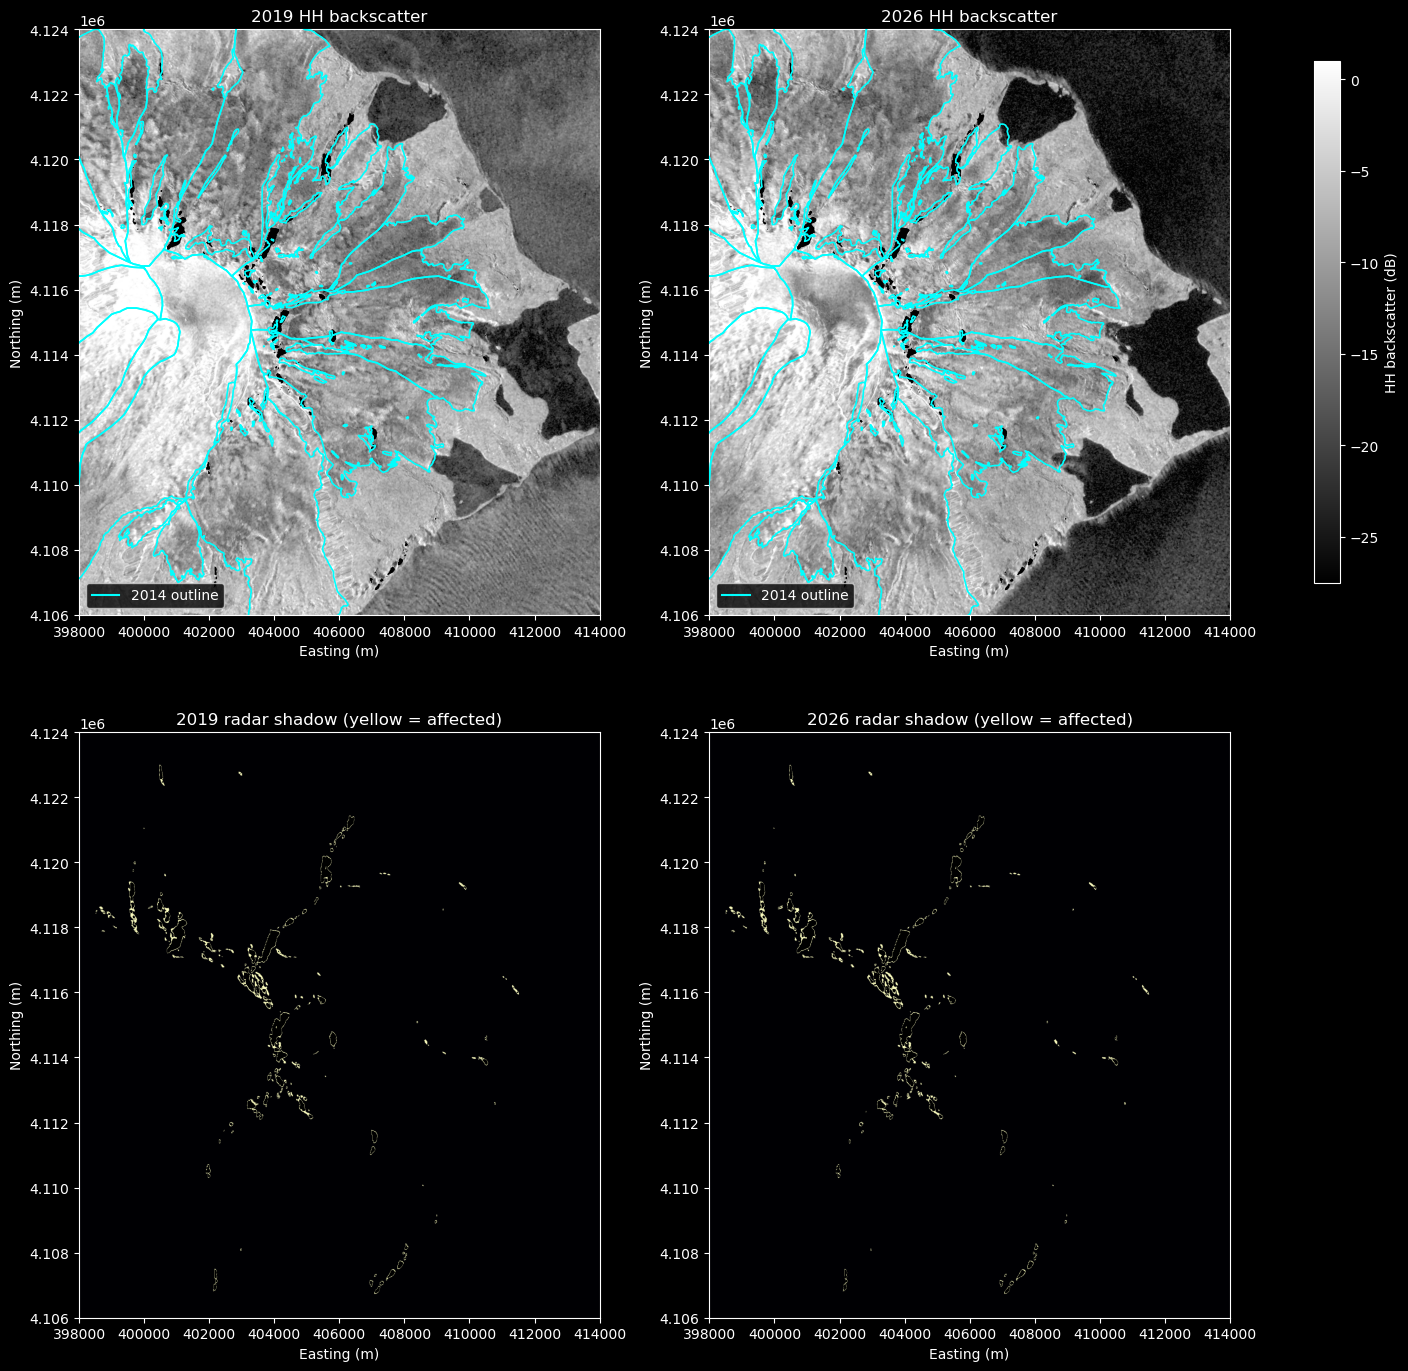

In [21]:
## Inspect eastern glacier margins against the 2014 outlines ##

# These bounds select a pilot area on the eastern slopes.
# Coordinates are metres in EPSG:32743; we can refine them after viewing.
crop_bounds = (398000, 4106000, 414000, 4124000)

# Use the named 2014 inventory from the current project folder.
# The other shapefile contains mixed 1947–2014 historical records.
outline_path = Path("Input_Data/heard_island_shp/Glacier_2014.shp")

mosaic_paths = {
    2019: Path("data/processed/S1A_IW_HH_2019-04-13_RTC_10m.tif"),
    2026: Path("data/processed/S1A_IW_HH_2026-04-12_RTC_10m.tif")
}

if not outline_path.exists():
    raise FileNotFoundError(f"2014 outline not found: {outline_path}")

# Load glacier names and geometries, then project them onto the SAR grid.
glaciers_2014 = gpd.read_file(outline_path)[
    ["RGIId", "name_1", "geometry"]].copy()

if glaciers_2014.crs is None:
    raise ValueError("The 2014 outline has no defined CRS")

glaciers_2014["geometry"] = glaciers_2014.geometry.make_valid()

crops = {}
reference_grid = None

for year, path in mosaic_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"{year} mosaic not found: {path}")

    with rasterio.open(path) as source:
        # Matching dimensions alone are insufficient: pixels must align too.
        grid = (
            source.crs,
            source.transform,
            source.width,
            source.height)

        if reference_grid is None:
            reference_grid = grid
            glaciers_2014 = glaciers_2014.to_crs(source.crs)
        elif grid != reference_grid:
            raise ValueError(f"{year} mosaic does not match the 2019 grid")

        # Read the crop at its native 10 m resolution.
        window = rasterio.windows.from_bounds(
            *crop_bounds,
            transform = source.transform).round_offsets().round_lengths()

        hh, shadow, data_mask = source.read(
            [1, 2, 3],
            window = window)

        # Keep real observations; exclude NoData from the display scale.
        valid = (
            (data_mask > 0.5) &
            np.isfinite(hh) &
            (hh > -90))

        if not valid.any():
            raise ValueError(f"No valid {year} pixels inside the crop")

        crops[year] = (hh, shadow, valid)
        plot_bounds = rasterio.windows.bounds(window, source.transform)

        print(
            f"{year}: {hh.shape[1]} × {hh.shape[0]} pixels; "
            f"{(shadow[valid] > 0.5).mean():.1%} radar shadow")

# Select outlines touching the crop; keep their names for orientation.
glaciers_crop = glaciers_2014.cx[
    crop_bounds[0]:crop_bounds[2],
    crop_bounds[1]:crop_bounds[3]]

if glaciers_crop.empty:
    raise ValueError("No 2014 glacier outlines intersect these crop bounds")

print(
    "2014 glaciers in view:",
    ", ".join(sorted(glaciers_crop["name_1"].dropna().unique())))

# Use one HH scale across both years, excluding shadow from the stretch.
hh_values = np.concatenate([
    hh[valid & (shadow <= 0.5)]
    for hh, shadow, valid in crops.values()
])

vmin, vmax = np.percentile(hh_values, [2, 98])

plot_extent = (
    plot_bounds[0], plot_bounds[2],
    plot_bounds[1], plot_bounds[3])

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(
        2, 2,
        figsize = (14, 14),
        constrained_layout = True)

    for column, year in enumerate(mosaic_paths):
        hh, shadow, valid = crops[year]

        # Top row: backscatter with the historical outline in cyan.
        hh_image = axes[0, column].imshow(
            np.ma.masked_where(~valid, hh),
            extent = plot_extent,
            origin = "upper",
            cmap = "gray",
            vmin = vmin,
            vmax = vmax)

        glaciers_crop.boundary.plot(
            ax = axes[0, column],
            color = "cyan",
            linewidth = 1.2,
            zorder = 3)

        axes[0, column].plot(
            [], [],
            color = "cyan",
            label = "2014 outline")

        axes[0, column].legend(loc = "lower left")
        axes[0, column].set_title(f"{year} HH backscatter")

        # Bottom row: check whether dark areas are radar shadow.
        axes[1, column].imshow(
            np.ma.masked_where(~valid, shadow),
            extent = plot_extent,
            origin = "upper",
            cmap = "magma",
            vmin = 0,
            vmax = 1)

        axes[1, column].set_title(
            f"{year} radar shadow (yellow = affected)")

        # The full glacier polygons extend beyond this crop.
        # Hold the axes to the raster window after plotting their edges.
        for ax in axes[:, column]:
            ax.set_xlim(plot_extent[0], plot_extent[1])
            ax.set_ylim(plot_extent[2], plot_extent[3])
            ax.set_xlabel("Easting (m)")
            ax.set_ylabel("Northing (m)")

    fig.colorbar(
        hh_image,
        ax = axes[0, :],
        shrink = 0.8,
        label = "HH backscatter (dB)")

    plt.show()

Stephenson inspection bounds: (np.float64(402184.16000000946), np.float64(4113164.580000256), np.float64(411613.4742082383), np.float64(4117414.716558771))
2019 crop: 943 × 425 pixels
2026 crop: 943 × 425 pixels


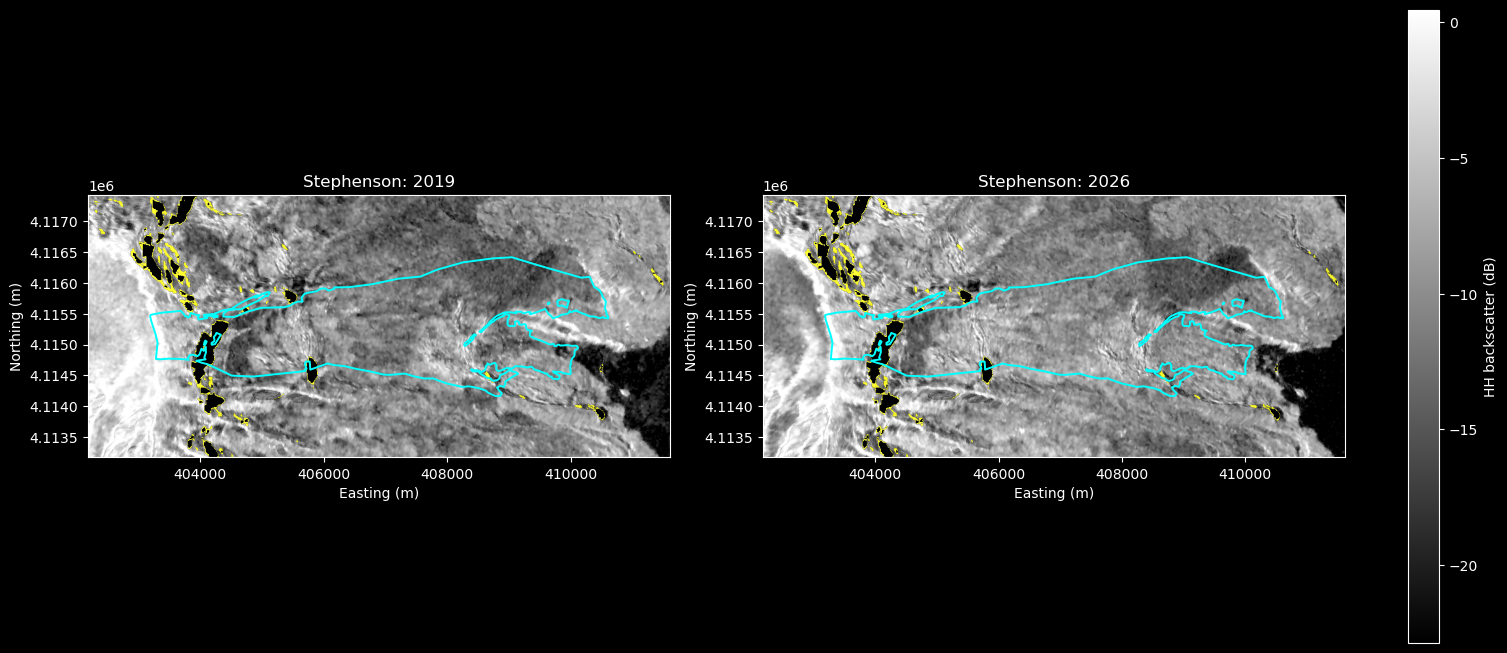

In [22]:
## Inspect Stephenson Glacier at full resolution ##

# Select the named 2014 polygon and leave room around its margins.
target_name = "Stephenson"
outline = glaciers_2014.loc[
    glaciers_2014["name_1"] == target_name].copy()

if len(outline) != 1:
    raise ValueError(
        f"Expected one {target_name} outline; found {len(outline)}")

left, bottom, right, top = outline.total_bounds
margin = 1000

glacier_bounds = (
    left - margin,
    bottom - margin,
    right + margin,
    top + margin)

print(f"{target_name} inspection bounds: {glacier_bounds}")

images = {}
reference_grid = None

for year, path in mosaic_paths.items():
    with rasterio.open(path) as source:
        # Both years must use the same CRS and pixel grid.
        grid = (
            source.crs,
            source.transform,
            source.width,
            source.height)

        if reference_grid is None:
            reference_grid = grid
        elif grid != reference_grid:
            raise ValueError("The 2019 and 2026 grids differ")

        if outline.crs != source.crs:
            raise ValueError("The outline and raster CRSs differ")

        # Read just Stephenson and its surrounding terrain.
        window = rasterio.windows.from_bounds(
            *glacier_bounds,
            transform = source.transform).round_offsets().round_lengths()

        hh, shadow, data_mask = source.read(
            [1, 2, 3],
            window = window)

        valid = (
            (data_mask > 0.5) &
            np.isfinite(hh) &
            (hh > -90))

        if not valid.any():
            raise ValueError(f"No valid pixels in the {year} crop")

        images[year] = (hh, shadow, valid)
        plot_bounds = rasterio.windows.bounds(window, source.transform)

        print(f"{year} crop: {hh.shape[1]} × {hh.shape[0]} pixels")

# Stretch both images using the same non-shadowed HH range.
hh_values = np.concatenate([
    hh[valid & (shadow <= 0.5)]
    for hh, shadow, valid in images.values()
])

vmin, vmax = np.percentile(hh_values, [2, 98])

plot_extent = (
    plot_bounds[0], plot_bounds[2],
    plot_bounds[1], plot_bounds[3])

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(
        1, 2,
        figsize = (15, 8),
        constrained_layout = True)

    for ax, year in zip(axes, mosaic_paths):
        hh, shadow, valid = images[year]

        # Cyan is the 2014 boundary; yellow marks radar shadow.
        image = ax.imshow(
            np.ma.masked_where(~valid, hh),
            extent = plot_extent,
            origin = "upper",
            cmap = "gray",
            vmin = vmin,
            vmax = vmax)

        ax.imshow(
            np.ma.masked_where((shadow <= 0.5) | ~valid, shadow),
            extent = plot_extent,
            origin = "upper",
            cmap = "autumn",
            vmin = 0,
            vmax = 1,
            alpha = 0.8)

        outline.boundary.plot(
            ax = ax,
            color = "cyan",
            linewidth = 1.4,
            zorder = 3)

        # Keep the display centred on the raster crop after plotting.
        ax.set_xlim(plot_extent[0], plot_extent[1])
        ax.set_ylim(plot_extent[2], plot_extent[3])
        ax.set_title(f"{target_name}: {year}")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    fig.colorbar(
        image,
        ax = axes,
        shrink = 0.8,
        label = "HH backscatter (dB)")

    plt.show()
    

## "Fuck, this isn't going to work. Find another way."

## Why we added a coherence workflow

Our 2019 and 2026 Sentinel-1 IW HH mosaics cover the whole island and use the same ascending orbit. However, HH backscatter alone does not consistently distinguish glacier ice from wet snow, debris and surrounding terrain. The mosaics were made from GRD data, which do not retain the radar phase needed to calculate interferometric coherence.

Coherence compares two radar acquisitions from the same orbit. A changing or moving glacier surface may have lower coherence than stable rock, providing another clue to the glacier margin. This is supporting evidence, not an automatic glacier outline: snowfall, melt and radar geometry can also affect coherence.

We found matching 12-day SLC pairs for **1–13 April 2019** and **31 March–12 April 2026**. A burst-level catalogue check confirmed that all 30 HH bursts match within each pair and jointly cover 100% of our mosaic rectangle. This check established that the scenes can be compared across the full study area; we did not download or process individual bursts.

Copernicus's published example referred to an older `card_coh12_public` workflow that was absent from the live API. We inspected the available `card_cohinf` workflow and ordered its `CARD_COH` output with a 12-day interval. Copernicus processes the full SLC pairs on its servers and provides terrain-corrected coherence rasters. Once downloaded, we will compare these with HH backscatter, terrain and available optical imagery before proposing 2019 and 2026 outlines.

In [23]:
## Check full-island SLC coverage for 12-day pairs ##

# Use the completed mosaic as the exact area we want to cover.
mosaic_path = "data/processed/S1A_IW_HH_2019-04-13_RTC_10m.tif"

with rasterio.open(mosaic_path) as source:
    map_crs = source.crs
    map_area = box(*source.bounds)
    search_bbox = transform_bounds(
        map_crs, "EPSG:4326", *source.bounds)

# These dates correspond to the matching orbit-100 GRD passes.
pair_dates = {
    2019: ("2019-04-01", "2019-04-13"),
    2026: ("2026-03-31", "2026-04-12")
}

catalogue = Client.open("https://stac.dataspace.copernicus.eu/v1")
slc_scenes = {}

for year, dates in pair_dates.items():
    for date in dates:
        # A one-hour window keeps each catalogue request small.
        search = catalogue.search(
            collections = ["sentinel-1-slc"],
            bbox = search_bbox,
            datetime = f"{date}T14:00:00Z/{date}T15:00:00Z",
            max_items = 100)

        slc_scenes[date] = [
            item for item in search.items()
            if item.id.startswith("S1A_IW_SLC__1SSH_")
            and int(item.properties.get("sat:relative_orbit", -1)) == 100
            and "HH" in item.properties.get("sar:polarizations", [])
            and item.properties.get("sat:orbit_state") == "ascending"
        ]

        print(f"\n{date}: {len(slc_scenes[date])} matching SLC product(s)")

        for item in slc_scenes[date]:
            print(" ", item.id)

    # Measure coverage in the mosaic's projected coordinate system.
    first_date, second_date = dates
    footprints = []

    for date in dates:
        geometries = [
            shape(transform_geom(
                "EPSG:4326", map_crs, item.geometry))
            for item in slc_scenes[date]
        ]

        footprints.append(
            unary_union(geometries) if geometries else None)

    if all(footprint is not None for footprint in footprints):
        shared_area = footprints[0].intersection(footprints[1])
        coverage = shared_area.intersection(map_area).area / map_area.area
    else:
        coverage = 0.0

    print(f"{year} pair coverage of mosaic rectangle: {coverage:.1%}")


2019-04-01: 1 matching SLC product(s)
  S1A_IW_SLC__1SSH_20190401T141917_20190401T141946_026597_02FB8B_3BB0

2019-04-13: 1 matching SLC product(s)
  S1A_IW_SLC__1SSH_20190413T141917_20190413T141947_026772_0301F3_13C5


TypeError: 'tuple' object is not callable

In [38]:
## Check matching SLC bursts ##

# Query bursts belonging to each of the four SLC products.
burst_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Bursts"
bursts_by_date = {}

for dates in pair_dates.values():
    for date in dates:
        product_name = f"{slc_scenes[date][0].id}.SAFE"

        parameters = {
            "$filter": (
                f"ParentProductName eq '{product_name}' "
                "and PolarisationChannels eq 'HH'"
            ),
            "$top": 200
        }

        url = burst_url
        rows = []

        # Follow another page if the catalogue returns one.
        while url:
            response = requests.get(
                url, params = parameters, timeout = 60)
            response.raise_for_status()

            page = response.json()
            rows.extend(page.get("value", []))
            url = page.get("@OData.nextLink")
            parameters = None

        # A burst ID repeats at the same position on later passes.
        bursts_by_date[date] = {}

        for row in rows:
            key = (row["SwathIdentifier"], row["BurstId"])
            footprint = shape(transform_geom(
                "EPSG:4326", map_crs, row["GeoFootprint"]))

            bursts_by_date[date].setdefault(key, []).append(
                footprint)

        print(f"{date}: {len(rows)} HH burst records")

# Check which positions occur on both dates of each pair.
for year, (first_date, second_date) in pair_dates.items():
    first = bursts_by_date[first_date]
    second = bursts_by_date[second_date]
    shared_keys = sorted(first.keys() & second.keys())

    shared_footprints = [
        unary_union(first[key]).intersection(
            unary_union(second[key]))
        for key in shared_keys
    ]

    if shared_footprints:
        shared_area = unary_union(shared_footprints)
        coverage = shared_area.intersection(
            map_area).area / map_area.area
    else:
        coverage = 0.0

    print(f"\n{year}: {len(shared_keys)} matching HH bursts")
    print(f"Matched-burst coverage of mosaic rectangle: {coverage:.1%}")
    print("Bursts by swath:", {
        swath: sum(key[0] == swath for key in shared_keys)
        for swath in ("IW1", "IW2", "IW3")
    })

2019-04-01: 30 HH burst records
2019-04-13: 30 HH burst records
2026-03-31: 30 HH burst records
2026-04-12: 30 HH burst records

2019: 30 matching HH bursts
Matched-burst coverage of mosaic rectangle: 100.0%
Bursts by swath: {'IW1': 10, 'IW2': 10, 'IW3': 10}

2026: 30 matching HH bursts
Matched-burst coverage of mosaic rectangle: 100.0%
Bursts by swath: {'IW1': 10, 'IW2': 10, 'IW3': 10}


In [48]:
## Authenticate for Copernicus on-demand processing ##

# This is your CDSE account login, not the OAuth client ID.
cdse_username = input("Copernicus account email: ")
cdse_password = getpass("Copernicus account password: ")

token_response = requests.post(
    "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/"
    "protocol/openid-connect/token",
    data = {
        "client_id": "cdse-public",
        "username": cdse_username,
        "password": cdse_password,
        "grant_type": "password"
    },
    timeout = 30)

del cdse_password
token_response.raise_for_status()

odp_token = token_response.json()["access_token"]
odp_headers = {"Authorization": f"Bearer {odp_token}"}

# Confirm that this account can see the exact processing workflow.
workflow_response = requests.get(
    "https://odp.dataspace.copernicus.eu/odata/v1/Workflows",
    headers = odp_headers,
    params = {"$filter": "Name eq 'card_cohinf'"},
    timeout = 30)

workflow_response.raise_for_status()
workflows = workflow_response.json().get("value", [])

if not workflows:
    raise RuntimeError(
        "CARD-COH12 is not available to this account")

print("Ready:", workflows[0]["Name"])

Ready: card_cohinf


In [45]:
## Order full-island coherence for 2019 and 2026 ##

# Save order IDs so a rerun cannot accidentally submit them twice.
orders_path = Path("data/processed/coherence_orders.json")
orders_path.parent.mkdir(parents = True, exist_ok = True)

if orders_path.exists():
    coherence_orders = json.loads(orders_path.read_text())
else:
    coherence_orders = {}

order_url = (
    "https://odp.dataspace.copernicus.eu/odata/v1/"
    "ProductionOrder/OData.CSC.Order"
)

for year, (first_date, second_date) in pair_dates.items():
    year_key = str(year)

    if year_key in coherence_orders:
        print(f"{year}: already ordered "
              f"({coherence_orders[year_key]['id']})")
        continue

    # The service finds the matching SLC from 12 days earlier.
    later_product = f"{slc_scenes[second_date][0].id}.SAFE"

    payload = {
        "WorkflowName": "card_cohinf",
        "InputProductReference": {
            "Reference": later_product
        },
        "WorkflowOptions": [
            {"Name": "output_storage", "Value": "TEMPORARY"},
            {"Name": "source_type", "Value": "CATALOGUE"},
            {"Name": "card_producttype", "Value": "CARD_COH"},
            {"Name": "timespan", "Value": 12},
            {"Name": "multilook", "Value": 1},
            {"Name": "output_format", "Value": "GeoTIFF"},
            {"Name": "map_projection", "Value": "EPSG:32743"},
            {"Name": "pixel_spacing_in_meter", "Value": 10.0}
        ],
        "Priority": 0,
        "Name": f"Heard_Island_HH_coherence_{year}"
    }

    response = requests.post(
        order_url,
        headers = odp_headers,
        json = payload,
        timeout = 60)

    if not response.ok:
        raise RuntimeError(
            f"{year} order failed ({response.status_code}): "
            f"{response.text[:500]}")

    result = response.json().get("value", {})
    order_id = result.get("Id")

    if not order_id:
        raise RuntimeError(
            f"{year} order response has no ID: {response.text[:500]}")

    coherence_orders[year_key] = {
        "id": order_id,
        "later_product": later_product,
        "status": result.get("Status")
    }

    # Write after each successful submission, including if the
    # second submission subsequently fails.
    orders_path.write_text(json.dumps(
        coherence_orders, indent = 2))

    print(f"{year}: order {order_id} — {result.get('Status')}")

2019: already ordered (17763145)
2026: already ordered (17763166)


In [49]:
## Check coherence order status ##

orders_path = Path("data/processed/coherence_orders.json")
coherence_orders = json.loads(orders_path.read_text())

for year, order_info in coherence_orders.items():
    order_id = order_info["id"]

    response = requests.get(
        "https://odp.dataspace.copernicus.eu/odata/v1/"
        f"ProductionOrders({order_id})",
        headers = odp_headers,
        timeout = 30)

    response.raise_for_status()
    details = response.json()
    details = details.get("value", details)

    print(
        f"{year} — order {order_id}: "
        f"{details.get('Status')} | "
        f"{details.get('StatusMessage')}")

2019 — order 17763145: completed | Processing finished successfully
2026 — order 17763166: completed | Processing finished successfully


In [52]:
## Download completed coherence products ##

download_dir = Path("data/raw/coherence")
download_dir.mkdir(parents = True, exist_ok = True)

coherence_orders = json.loads(
    Path("data/processed/coherence_orders.json").read_text())

for year, order_info in coherence_orders.items():
    order_id = order_info["id"]
    output_path = download_dir / f"Heard_coherence_{year}.zip"
    temporary_path = download_dir / f"Heard_coherence_{year}.part"

    if output_path.exists() and zipfile.is_zipfile(output_path):
        print(f"{year}: already downloaded — {output_path}")
        continue

    url = (
        "https://odp.dataspace.copernicus.eu/odata/v1/"
        f"ProductionOrder({order_id})/Product/$value"
    )

    print(f"{year}: downloading order {order_id}...", flush = True)

    with requests.get(
        url,
        headers = odp_headers,
        stream = True,
        timeout = (30, 120)
    ) as response:
        response.raise_for_status()

        downloaded = 0
        next_report = 100 * 1024 * 1024

        with temporary_path.open("wb") as output:
            for chunk in response.iter_content(
                chunk_size = 1024 * 1024
            ):
                if not chunk:
                    continue

                output.write(chunk)
                downloaded += len(chunk)

                if downloaded >= next_report:
                    print(
                        f"  {downloaded / 1024**2:.0f} MiB...",
                        flush = True)
                    next_report += 100 * 1024 * 1024

    if not zipfile.is_zipfile(temporary_path):
        raise RuntimeError(
            f"{year}: download is not a valid ZIP: "
            f"{temporary_path}")

    temporary_path.replace(output_path)

    print(
        f"{year}: saved {output_path} "
        f"({output_path.stat().st_size / 1024**2:.1f} MiB)")

    # List the contents without extracting a large raster yet.
    with zipfile.ZipFile(output_path) as archive:
        for member in archive.infolist()[:12]:
            print(
                f"  {member.filename} "
                f"({member.file_size / 1024**2:.1f} MiB)")

2019: downloading order 17763145...
  100 MiB...
  200 MiB...
  300 MiB...
  400 MiB...
  500 MiB...
  600 MiB...
  700 MiB...
2019: saved data\raw\coherence\Heard_coherence_2019.zip (794.5 MiB)
  S1A_IW_SLC__1SSH_20190413T141917_20190413T141947_026772_0301F3_13C5_CARD_COH12.tif (797.2 MiB)
2026: downloading order 17763166...
  100 MiB...
  200 MiB...
  300 MiB...
  400 MiB...
  500 MiB...
  600 MiB...
  700 MiB...
2026: saved data\raw\coherence\Heard_coherence_2026.zip (703.3 MiB)
  S1A_IW_SLC__1SSH_20260412T141924_20260412T141954_064047_080EFF_4603_CARD_COH12.tif (706.1 MiB)


In [24]:
## Extract and inspect the coherence rasters ##

coherence_dir = Path("data/raw/coherence")

for year in (2019, 2026):
    archive_path = coherence_dir / f"Heard_coherence_{year}.zip"
    raster_path = coherence_dir / f"Heard_coherence_{year}.tif"
    temporary_path = coherence_dir / f"Heard_coherence_{year}.part.tif"

    with zipfile.ZipFile(archive_path) as archive:
        tif_members = [
            member for member in archive.infolist()
            if member.filename.lower().endswith(".tif")
        ]

        if len(tif_members) != 1:
            raise RuntimeError(
                f"{year}: expected one TIFF, found {len(tif_members)}")

        member = tif_members[0]

        if not (
            raster_path.exists()
            and raster_path.stat().st_size == member.file_size
        ):
            free_space = shutil.disk_usage(coherence_dir).free

            if free_space < member.file_size + 512 * 1024**2:
                raise RuntimeError(
                    f"{year}: insufficient free space to extract TIFF")

            print(f"{year}: extracting {member.file_size / 1024**2:.1f} MiB...")

            # Stream the raster to disk; do not load it into memory.
            with archive.open(member) as source:
                with temporary_path.open("wb") as target:
                    shutil.copyfileobj(
                        source, target, length = 8 * 1024**2)

            temporary_path.replace(raster_path)

    with rasterio.open(raster_path) as source:
        print(f"\n{year}: {raster_path}")
        print("  Shape:", source.count, source.height, source.width)
        print("  CRS:", source.crs)
        print("  Pixel size:", source.res)
        print("  Data types:", source.dtypes)
        print("  Band descriptions:", source.descriptions)
        print("  NoData:", source.nodata)
        print("  Bounds:", tuple(
            round(value, 1) for value in source.bounds))


2019: data\raw\coherence\Heard_coherence_2019.tif
  Shape: 1 28832 31656
  CRS: EPSG:32743
  Pixel size: (10.0, 10.0)
  Data types: ('float32',)
  Band descriptions: ('coh_HH',)
  NoData: 0.0
  Bounds: (263992.4, 3980959.0, 580552.4, 4269279.0)

2026: data\raw\coherence\Heard_coherence_2026.tif
  Shape: 1 28808 31672
  CRS: EPSG:32743
  Pixel size: (10.0, 10.0)
  Data types: ('float32',)
  Band descriptions: ('coh_HH',)
  NoData: 0.0
  Bounds: (271196.3, 3963577.9, 587916.3, 4251657.9)


2019: 100.0% valid in crop
  Coherence percentiles (10, 50, 90): [0.164 0.271 0.495]
2026: 100.0% valid in crop
  Coherence percentiles (10, 50, 90): [0.163 0.267 0.462]


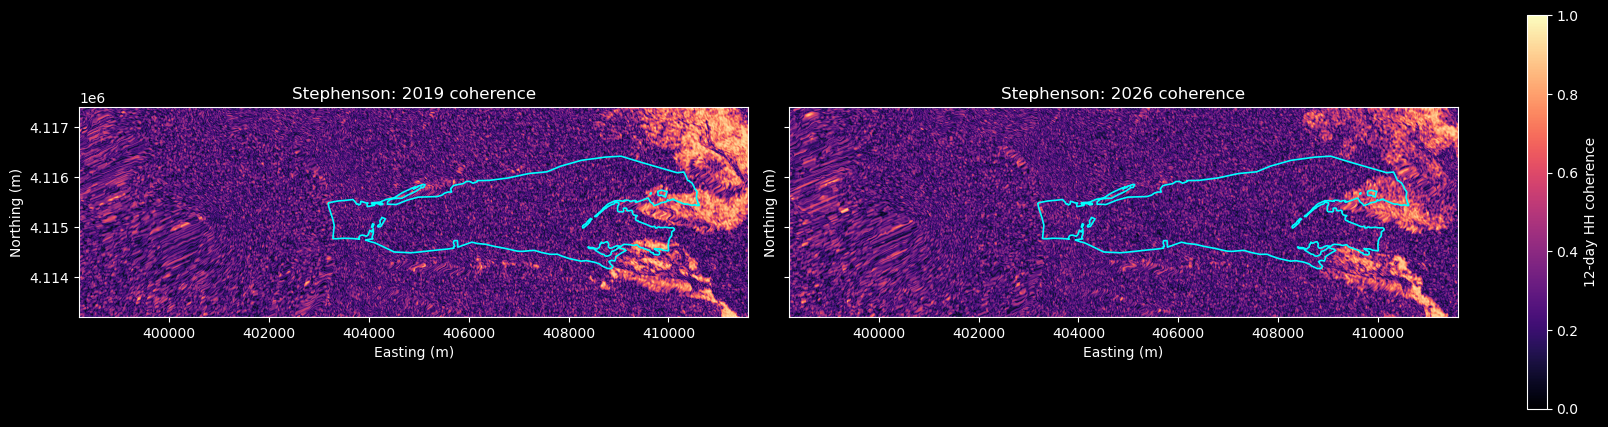

In [25]:
## Preview coherence around Stephenson Glacier ##

# Match the area shown in our earlier Stephenson comparison.
west, south, east, north = (
    398200, 4113200, 411600, 4117400)

preview_width = 670
preview_height = 210

preview_transform = from_bounds(
    west, south, east, north,
    preview_width, preview_height)

glaciers_2014 = gpd.read_file(
    "Input_Data/heard_island_shp/Glacier_2014.shp"
).to_crs("EPSG:32743")

stephenson_2014 = glaciers_2014.loc[
    glaciers_2014["name_1"].astype(str).str.lower()
    == "stephenson"
]

if stephenson_2014.empty:
    raise RuntimeError("Stephenson was not found in the 2014 outlines")

colour_map = plt.get_cmap("magma").copy()
colour_map.set_bad("#303030")

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(
        1, 2, figsize = (16, 5),
        sharex = True, sharey = True,
        layout = "constrained")

    for ax, year in zip(axes, (2019, 2026)):
        raster_path = (
            Path("data/raw/coherence")
            / f"Heard_coherence_{year}.tif"
        )

        with rasterio.open(raster_path) as source:
            # The VRT maps just this crop to one common display grid.
            with WarpedVRT(
                source,
                crs = source.crs,
                transform = preview_transform,
                width = preview_width,
                height = preview_height,
                resampling = Resampling.average
            ) as preview_source:
                coherence = preview_source.read(
                    1, masked = True)

        coherence = np.ma.masked_invalid(coherence)

        image = ax.imshow(
            coherence,
            extent = (west, east, south, north),
            origin = "upper",
            cmap = colour_map,
            vmin = 0,
            vmax = 1)

        stephenson_2014.boundary.plot(
            ax = ax, color = "cyan", linewidth = 1.2)

        values = coherence.compressed()
        print(
            f"{year}: {values.size / coherence.size:.1%} "
            f"valid in crop")

        if values.size:
            print(
                "  Coherence percentiles (10, 50, 90):",
                np.round(np.percentile(
                    values, [10, 50, 90]), 3))

        ax.set_title(f"Stephenson: {year} coherence")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        ax.set_xlim(west, east)
        ax.set_ylim(south, north)

    fig.colorbar(
        image, ax = axes, shrink = 0.8,
        label = "12-day HH coherence")

    plt.show()

C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3262743854.py:33: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hh = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3262743854.py:38: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data_mask = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3262743854.py:33: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hh = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3262743854.py:38: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a

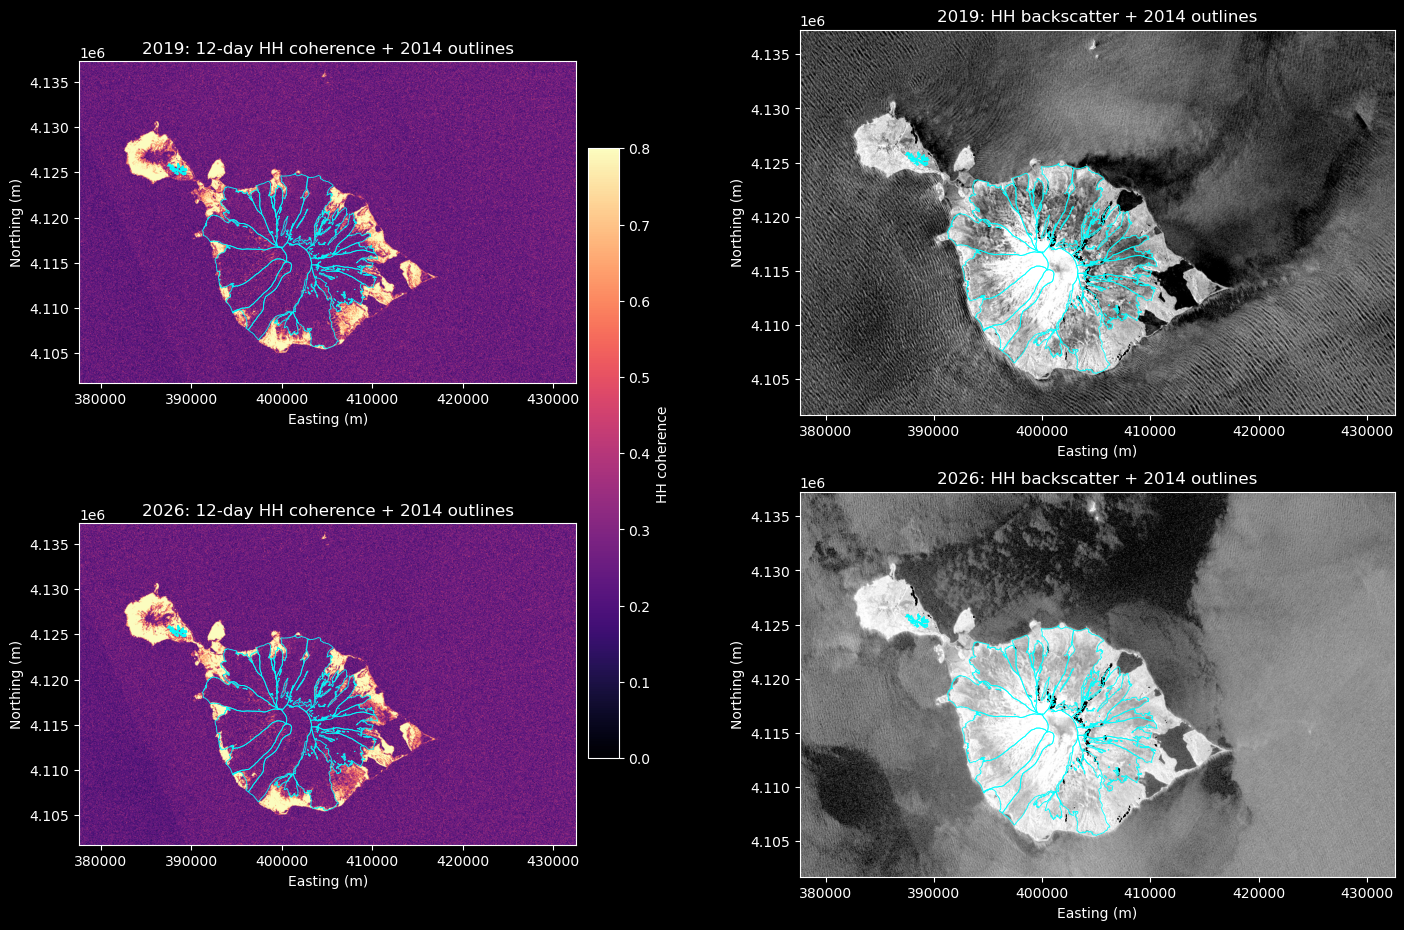

In [26]:
## Full-island SAR preview with 2014 glacier outlines ##

glacier_path = Path("Input_Data/heard_island_shp/Glacier_2014.shp")

radar_paths = {
    2019: Path("data/processed/S1A_IW_HH_2019-04-13_RTC_10m.tif"),
    2026: Path("data/processed/S1A_IW_HH_2026-04-12_RTC_10m.tif")}

coherence_paths = {
    2019: Path("data/raw/coherence/Heard_coherence_2019.tif"),
    2026: Path("data/raw/coherence/Heard_coherence_2026.tif")}

# Read the outlines once and put them in the mosaics' projected CRS.
with rasterio.open(radar_paths[2019]) as reference:
    map_crs = reference.crs

glaciers_2014 = gpd.read_file(glacier_path).to_crs(map_crs)

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(2, 2, figsize = (17, 11))

    for row, year in enumerate((2019, 2026)):
        with rasterio.open(radar_paths[year]) as radar:
            # About one quarter of the original width and height is plenty
            # for a full-island inspection.
            preview_width = max(1, radar.width // 4)
            preview_height = max(1, radar.height // 4)

            preview_transform = radar.transform * radar.transform.scale(
                radar.width / preview_width,
                radar.height / preview_height)

            hh = radar.read(
                1,
                out_shape = (preview_height, preview_width),
                resampling = Resampling.average)

            data_mask = radar.read(
                3,
                out_shape = (preview_height, preview_width),
                resampling = Resampling.nearest) > 0.5

            extent = (
                radar.bounds.left,
                radar.bounds.right,
                radar.bounds.bottom,
                radar.bounds.top)

            # Warp the coherence image directly onto this small preview grid.
            with rasterio.open(coherence_paths[year]) as coherence_source:
                with WarpedVRT(
                    coherence_source,
                    crs = radar.crs,
                    transform = preview_transform,
                    width = preview_width,
                    height = preview_height,
                    src_nodata = 0,
                    nodata = 0,
                    resampling = Resampling.average) as coherence_vrt:

                    coherence = coherence_vrt.read(1, masked = True)

        valid_hh = data_mask & np.isfinite(hh) & (hh > -90)
        hh_limits = np.percentile(hh[valid_hh], [2, 98])

        coherence = np.ma.masked_where(~data_mask, coherence)
        hh_display = np.ma.masked_where(~valid_hh, hh)

        coherence_image = axes[row, 0].imshow(
            coherence,
            extent = extent,
            origin = "upper",
            cmap = "magma",
            vmin = 0,
            vmax = 0.8)

        axes[row, 1].imshow(
            hh_display,
            extent = extent,
            origin = "upper",
            cmap = "gray",
            vmin = hh_limits[0],
            vmax = hh_limits[1])

        for ax in axes[row]:
            glaciers_2014.boundary.plot(
                ax = ax,
                color = "cyan",
                linewidth = 0.65,
                alpha = 0.9)

            ax.set_xlabel("Easting (m)")
            ax.set_ylabel("Northing (m)")

        axes[row, 0].set_title(f"{year}: 12-day HH coherence + 2014 outlines")
        axes[row, 1].set_title(f"{year}: HH backscatter + 2014 outlines")

    fig.colorbar(
        coherence_image,
        ax = axes[:, 0],
        label = "HH coherence",
        shrink = 0.72,
        pad = 0.02)

    plt.show()

This next cell is a Stephenson trial. It samples pixels well inside its 2014 outline as likely ice and pixels well outside all 2014 glacier outlines as likely non-ice. It uses local HH brightness, local HH variation, and coherence to draw a candidate connected to the glacier interior. The 2014 outline supplies training locations; it is not copied as the result. The draft files are for visual inspection, not area-change calculations yet.

Features: 3399
Geometry types: {'Polygon': 3399}
Fields: ['feat_type', 'name', 'source', 'date_capture', 'date_flag', 'metadata_id', 'feature_source', 'spatial_method', 'spat_reliability_date', 'att_reliability_date', 'attribute_source', 'planimetric_accuracy', 'elevation_accuracy', 'st_area', 'st_perimeter', 'geometry']


C:\Users\harry\AppData\Local\Temp\ipykernel_14664\1780726373.py:25: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hh = radar.read(1, window = window)


2014 glacier pixels inside coastline: 100.0%


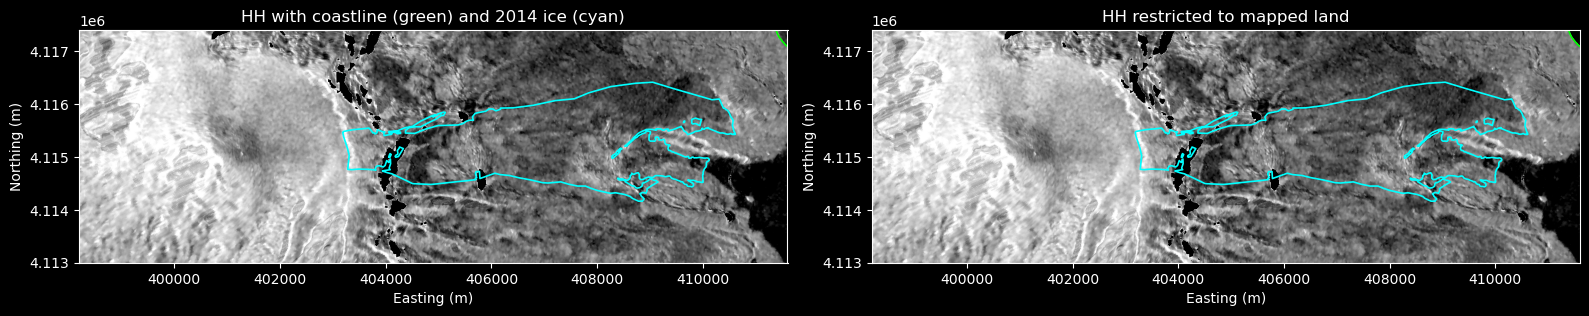

In [27]:
## Check the HIMI coastline against Stephenson ##

study_bounds = (398200, 4113000, 411600, 4117400)

stephenson_2014 = glaciers_2014.loc[
    glaciers_2014["name_1"].str.contains(
        "Stephenson",
        case = False,
        na = False)]

coast_path = Path("Input_Data/HIMI_Features/himi_coastline_py.gpkg")
coast = gpd.read_file(coast_path).to_crs(map_crs)

print("Features:", len(coast))
print("Geometry types:", coast.geom_type.value_counts().to_dict())
print("Fields:", coast.columns.tolist())

if not coast.geom_type.isin(["Polygon", "MultiPolygon"]).all():
    raise ValueError("This coastline layer does not contain only polygons")

with rasterio.open(radar_paths[2019]) as radar:
    window = radar.window(
        *study_bounds).round_offsets().round_lengths()

    hh = radar.read(1, window = window)
    crop_transform = radar.window_transform(window)
    left, bottom, right, top = radar.window_bounds(window)

land_mask = rasterize(
    [(geometry, 1) for geometry in coast.geometry],
    out_shape = hh.shape,
    transform = crop_transform,
    fill = 0).astype(bool)

ice_2014_mask = rasterize(
    [(geometry, 1) for geometry in glaciers_2014.geometry],
    out_shape = hh.shape,
    transform = crop_transform,
    fill = 0).astype(bool)

if not land_mask.any():
    raise RuntimeError("The coastline polygon misses the Stephenson crop")

print(
    "2014 glacier pixels inside coastline:",
    f"{land_mask[ice_2014_mask].mean():.1%}")

valid = np.isfinite(hh) & (hh > -90)
vmin, vmax = np.percentile(hh[valid], [2, 98])
extent = (left, right, bottom, top)

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize = (16, 5))

    axes[0].imshow(
        np.ma.masked_where(~valid, hh),
        extent = extent,
        origin = "upper",
        cmap = "gray",
        vmin = vmin,
        vmax = vmax)

    axes[1].imshow(
        np.ma.masked_where(~(valid & land_mask), hh),
        extent = extent,
        origin = "upper",
        cmap = "gray",
        vmin = vmin,
        vmax = vmax)

    for ax in axes:
        coast.boundary.plot(
            ax = ax,
            color = "lime",
            linewidth = 1.2)

        stephenson_2014.boundary.plot(
            ax = ax,
            color = "cyan",
            linewidth = 1.2)

        ax.set_xlim(left, right)
        ax.set_ylim(bottom, top)
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    axes[0].set_title("HH with coastline (green) and 2014 ice (cyan)")
    axes[1].set_title("HH restricted to mapped land")

    fig.tight_layout()
    plt.show()

In [28]:
## Map candidate exposed rock across the whole island ##

coast_path = Path("Input_Data/HIMI_Features/himi_coastline_py.gpkg")

# This DEM was used in the earlier Heard Island assignment.
dem_matches = sorted(Path("Input_Data").rglob("HI_dem2019.tif"))
dem_matches += sorted(Path("Data/Spatial").glob("HI_dem2019.tif"))

if not dem_matches:
    raise FileNotFoundError(
        "HI_dem2019.tif is missing from this project. Copy it from the "
        "earlier assignment's Data/Spatial folder into Input_Data.")

dem_path = dem_matches[0]
coast = gpd.read_file(coast_path).to_crs(map_crs)

if not coast.geom_type.isin(["Polygon", "MultiPolygon"]).all():
    raise ValueError("The coastline layer must contain land polygons")

coast_geometries = [
    geometry for geometry in coast.geometry
    if geometry is not None and not geometry.is_empty]

output_paths = {}

for year in (2019, 2026):
    output_path = Path(
        f"data/processed/Heard_SAR_rock_candidate_{year}_10m.tif")

    temporary_path = output_path.with_name(
        f"{output_path.stem}_building.tif")

    output_path.parent.mkdir(parents = True, exist_ok = True)

    # A leftover temporary file is incomplete and may be safely replaced.
    if temporary_path.exists():
        temporary_path.unlink()

    with rasterio.open(radar_paths[year]) as radar:
        with rasterio.open(coherence_paths[year]) as coherence_source:
            with rasterio.open(dem_path) as dem_source:
                # Both other rasters are read on the full-island HH grid.
                with WarpedVRT(
                    coherence_source,
                    crs = radar.crs,
                    transform = radar.transform,
                    width = radar.width,
                    height = radar.height,
                    src_nodata = 0,
                    nodata = 0,
                    resampling = Resampling.bilinear) as coherence_vrt:

                    with WarpedVRT(
                        dem_source,
                        crs = radar.crs,
                        transform = radar.transform,
                        width = radar.width,
                        height = radar.height,
                        src_nodata = dem_source.nodata,
                        nodata = -9999,
                        resampling = Resampling.bilinear) as dem_vrt:

                        # Use explicit TIFF blocks divisible by 16.
                        profile = {
                            "driver": "GTiff",
                            "height": radar.height,
                            "width": radar.width,
                            "count": 1,
                            "dtype": "uint8",
                            "crs": radar.crs,
                            "transform": radar.transform,
                            "nodata": 0,
                            "tiled": True,
                            "blockxsize": 256,
                            "blockysize": 256,
                            "compress": "deflate"}

                        counts = np.zeros(5, dtype = "int64")

                        with rasterio.open(
                            temporary_path,
                            "w",
                            **profile) as destination:

                            for row in range(0, radar.height, 512):
                                window = Window(
                                    0,
                                    row,
                                    radar.width,
                                    min(512, radar.height - row))

                                window_shape = (
                                    int(window.height),
                                    int(window.width))

                                window_transform = radar.window_transform(
                                    window)

                                # Rasterise the coastline on this exact
                                # section of the full-island radar grid.
                                land = rasterize(
                                    [(geometry, 1)
                                     for geometry in coast_geometries],
                                    out_shape = window_shape,
                                    transform = window_transform,
                                    fill = 0).astype(bool)

                                data = radar.read(
                                    3,
                                    window = window) > 0.5

                                shadow = radar.read(
                                    2,
                                    window = window) > 0.5

                                coherence = coherence_vrt.read(
                                    1,
                                    window = window,
                                    masked = True).astype(
                                        "float32").filled(np.nan)

                                elevation = dem_vrt.read(
                                    1,
                                    window = window,
                                    masked = True).astype(
                                        "float32").filled(np.nan)

                                valid = (
                                    land
                                    & data
                                    & ~shadow
                                    & np.isfinite(coherence)
                                    & (coherence > 0)
                                    & np.isfinite(elevation)
                                    & (elevation >= 0))

                                low_land = valid & (elevation < 750)
                                high_land = valid & (elevation >= 750)
                                rock = low_land & (coherence > 0.25)

                                # 0 = outside mapped land
                                # 1 = low-coherence land below 750 m
                                # 2 = candidate rock below 750 m
                                # 3 = land at or above 750 m, not assessed
                                # 4 = mapped land lacking usable observations
                                classes = np.zeros(
                                    window_shape,
                                    dtype = "uint8")

                                classes[land] = 4
                                classes[high_land] = 3
                                classes[low_land] = 1
                                classes[rock] = 2

                                destination.write(
                                    classes,
                                    1,
                                    window = window)

                                counts += np.bincount(
                                    classes.ravel(),
                                    minlength = 5)

    # Publish only after every chunk has been written successfully.
    temporary_path.replace(output_path)
    output_paths[year] = output_path

    lowland_count = counts[1] + counts[2]

    if lowland_count == 0:
        raise RuntimeError(
            f"{year}: no valid land below 750 m; check DEM coverage")

    print(f"{year}: saved {output_path}")
    print(
        f"  Candidate rock: {counts[2] / lowland_count:.1%} "
        "of evaluated land below 750 m")
    print(
        f"  Unresolved low-coherence land: "
        f"{counts[1] / lowland_count:.1%}")

C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:108: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:112: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  shadow = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:108: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:112: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create 

2019: saved data\processed\Heard_SAR_rock_candidate_2019_10m.tif
  Candidate rock: 69.9% of evaluated land below 750 m
  Unresolved low-coherence land: 30.1%


C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:108: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:112: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  shadow = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:108: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\744627794.py:112: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create 

2026: saved data\processed\Heard_SAR_rock_candidate_2026_10m.tif
  Candidate rock: 71.0% of evaluated land below 750 m
  Unresolved low-coherence land: 29.0%


C:\Users\harry\AppData\Local\Temp\ipykernel_14664\4016661220.py:20: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  preview = source.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\4016661220.py:20: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  preview = source.read(


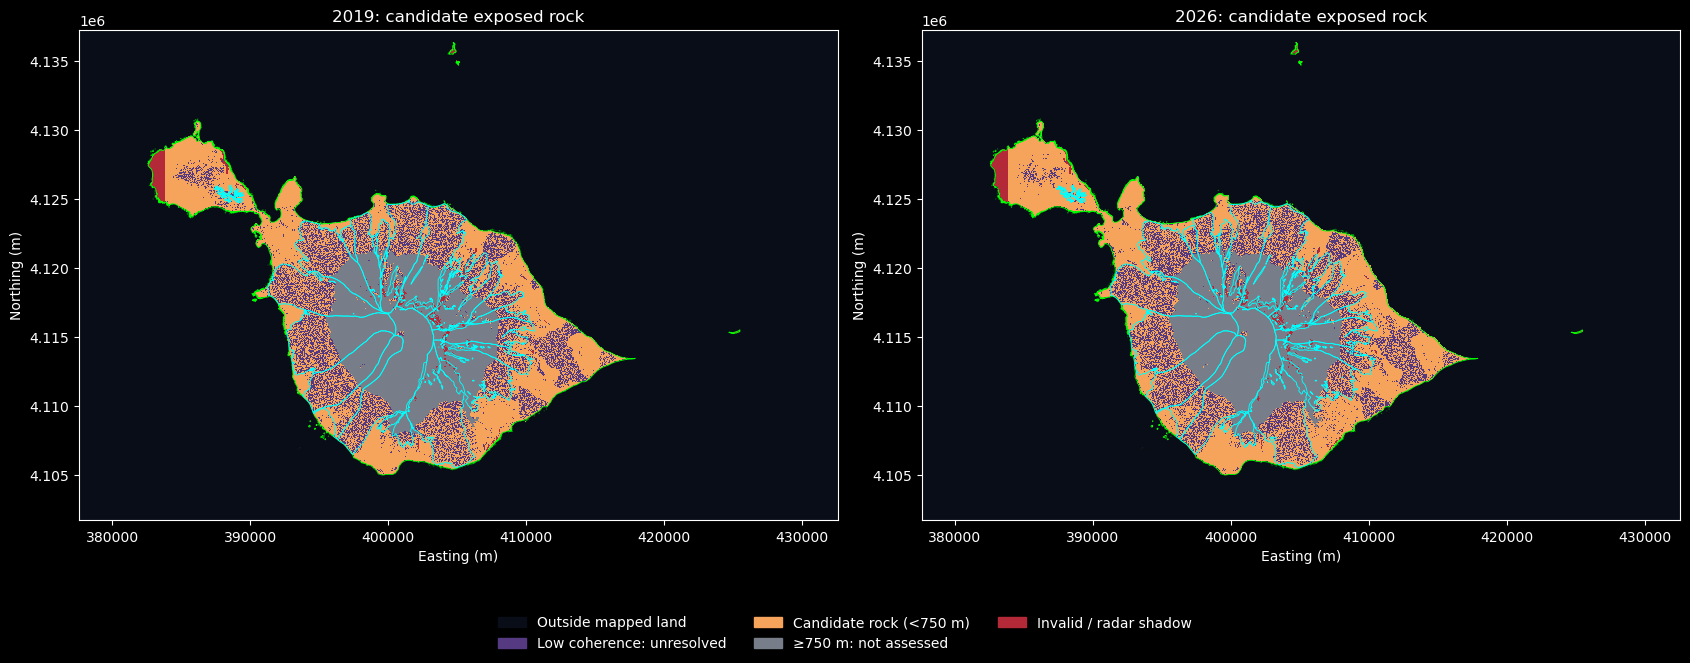

In [29]:
## Preview the full-island candidate rock maps ##

colours = [
    "#090D17",  # Outside mapped land
    "#553A82",  # Low-coherence land
    "#F6A35B",  # Candidate rock
    "#777E89",  # High elevation, not assessed
    "#B32937"]  # Invalid data or radar shadow

colourmap = ListedColormap(colours)
colour_norm = BoundaryNorm(
    np.arange(-0.5, 5.5, 1),
    colourmap.N)

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize = (17, 7))

    for ax, year in zip(axes, (2019, 2026)):
        with rasterio.open(output_paths[year]) as source:
            preview = source.read(
                1,
                out_shape = (
                    max(1, source.height // 4),
                    max(1, source.width // 4)),
                resampling = Resampling.nearest)

            extent = (
                source.bounds.left,
                source.bounds.right,
                source.bounds.bottom,
                source.bounds.top)

        ax.imshow(
            preview,
            extent = extent,
            origin = "upper",
            cmap = colourmap,
            norm = colour_norm,
            interpolation = "nearest")

        coast.boundary.plot(
            ax = ax,
            color = "lime",
            linewidth = 0.6)

        glaciers_2014.boundary.plot(
            ax = ax,
            color = "cyan",
            linewidth = 0.65)

        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_title(f"{year}: candidate exposed rock")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    legend_items = [
        Patch(color = colours[0], label = "Outside mapped land"),
        Patch(color = colours[1], label = "Low coherence: unresolved"),
        Patch(color = colours[2], label = "Candidate rock (<750 m)"),
        Patch(color = colours[3], label = "≥750 m: not assessed"),
        Patch(color = colours[4], label = "Invalid / radar shadow")]

    fig.legend(
        handles = legend_items,
        loc = "lower center",
        ncol = 3,
        frameon = False)

    fig.tight_layout(rect = (0, 0.10, 1, 1))
    plt.show()

C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3358219176.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  classes = source.read(1, window = window)
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3358219176.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  classes = source.read(1, window = window)
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3358219176.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  classes = source.read(1, window = window)
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\3358219176.py:15: DeprecationWarning: Setting the shape on a NumPy array h

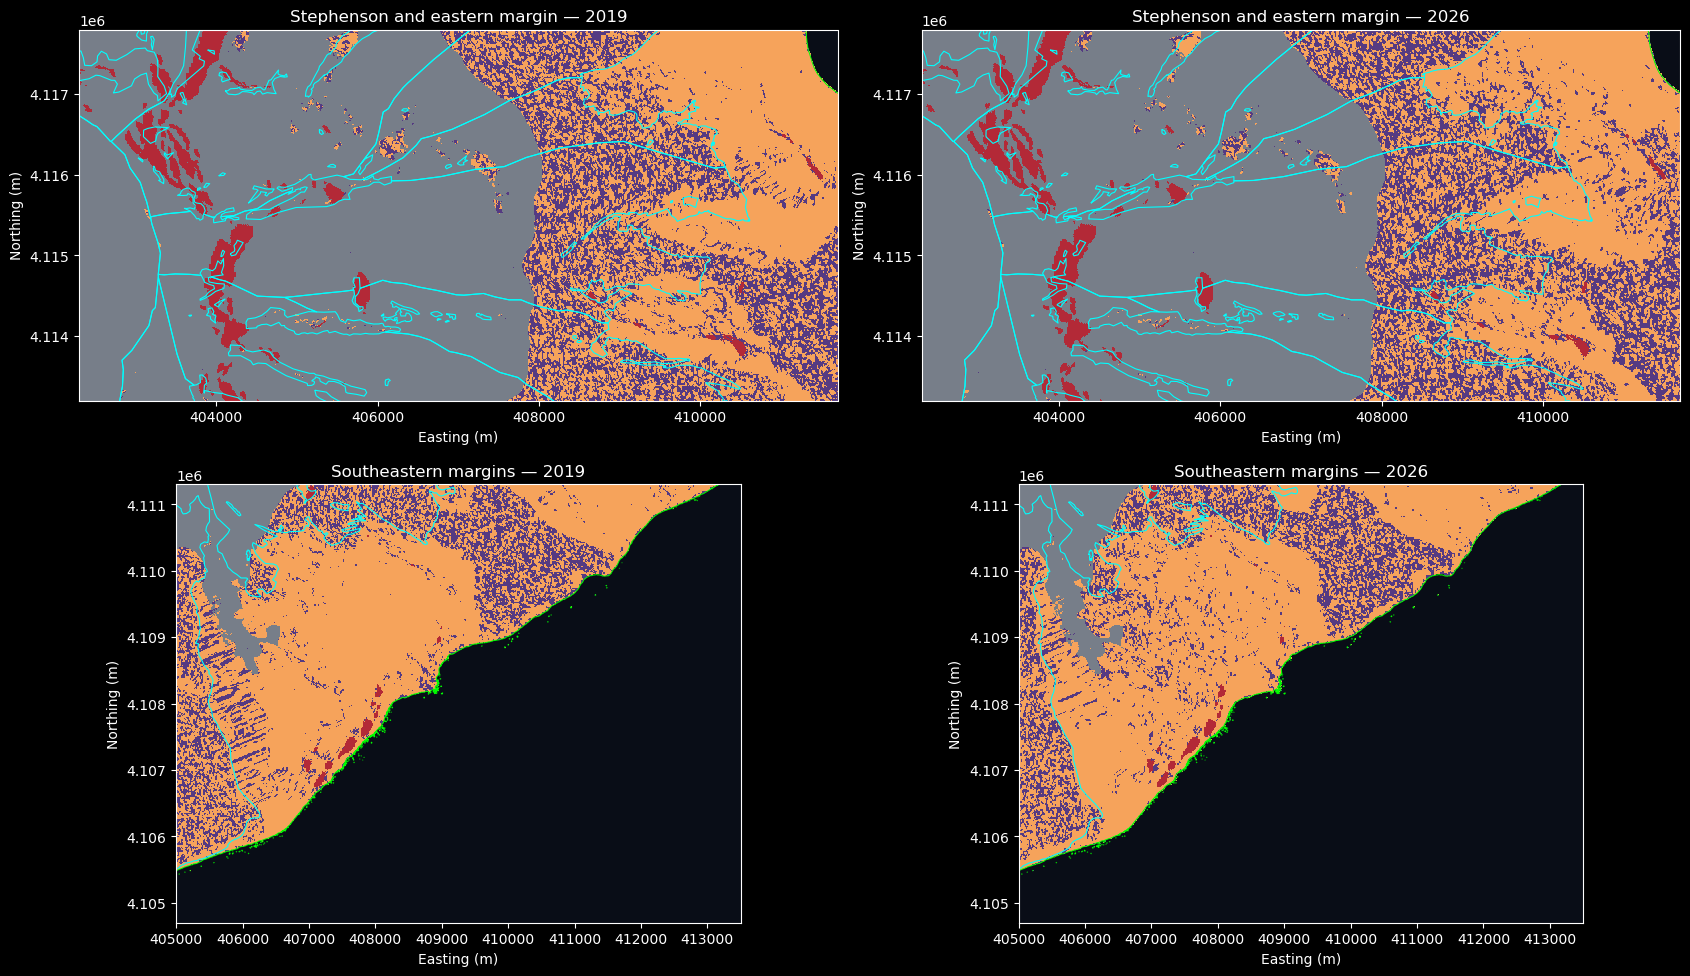

In [30]:
## Inspect the eastern glacier margins at 10 m ##

# Each rectangle is (left, bottom, right, top) in EPSG:32743 metres.
regions = {
    "Stephenson and eastern margin": (402300, 4113200, 411700, 4117800),
    "Southeastern margins": (405000, 4104700, 413500, 4111300)}

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(2, 2, figsize = (17, 10))

    for row, (region_name, bounds) in enumerate(regions.items()):
        for col, year in enumerate((2019, 2026)):
            with rasterio.open(output_paths[year]) as source:
                window = source.window(*bounds).round_offsets().round_lengths()
                classes = source.read(1, window = window)
                left, bottom, right, top = source.window_bounds(window)

            ax = axes[row, col]
            ax.imshow(
                classes,
                extent = (left, right, bottom, top),
                origin = "upper",
                cmap = colourmap,
                norm = colour_norm,
                interpolation = "nearest")

            coast.boundary.plot(ax = ax, color = "lime", linewidth = 0.7)
            glaciers_2014.boundary.plot(ax = ax, color = "cyan", linewidth = 0.8)

            ax.set_xlim(left, right)
            ax.set_ylim(bottom, top)
            ax.set_title(f"{region_name} — {year}")
            ax.set_xlabel("Easting (m)")
            ax.set_ylabel("Northing (m)")

    fig.tight_layout()
    plt.show()

C:\Users\harry\AppData\Local\Temp\ipykernel_14664\4190950165.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  classes = source.read(1, window = window)


2019: 15.1% of evaluated pixels changed in this view


C:\Users\harry\AppData\Local\Temp\ipykernel_14664\4190950165.py:15: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  classes = source.read(1, window = window)


2026: 14.8% of evaluated pixels changed in this view


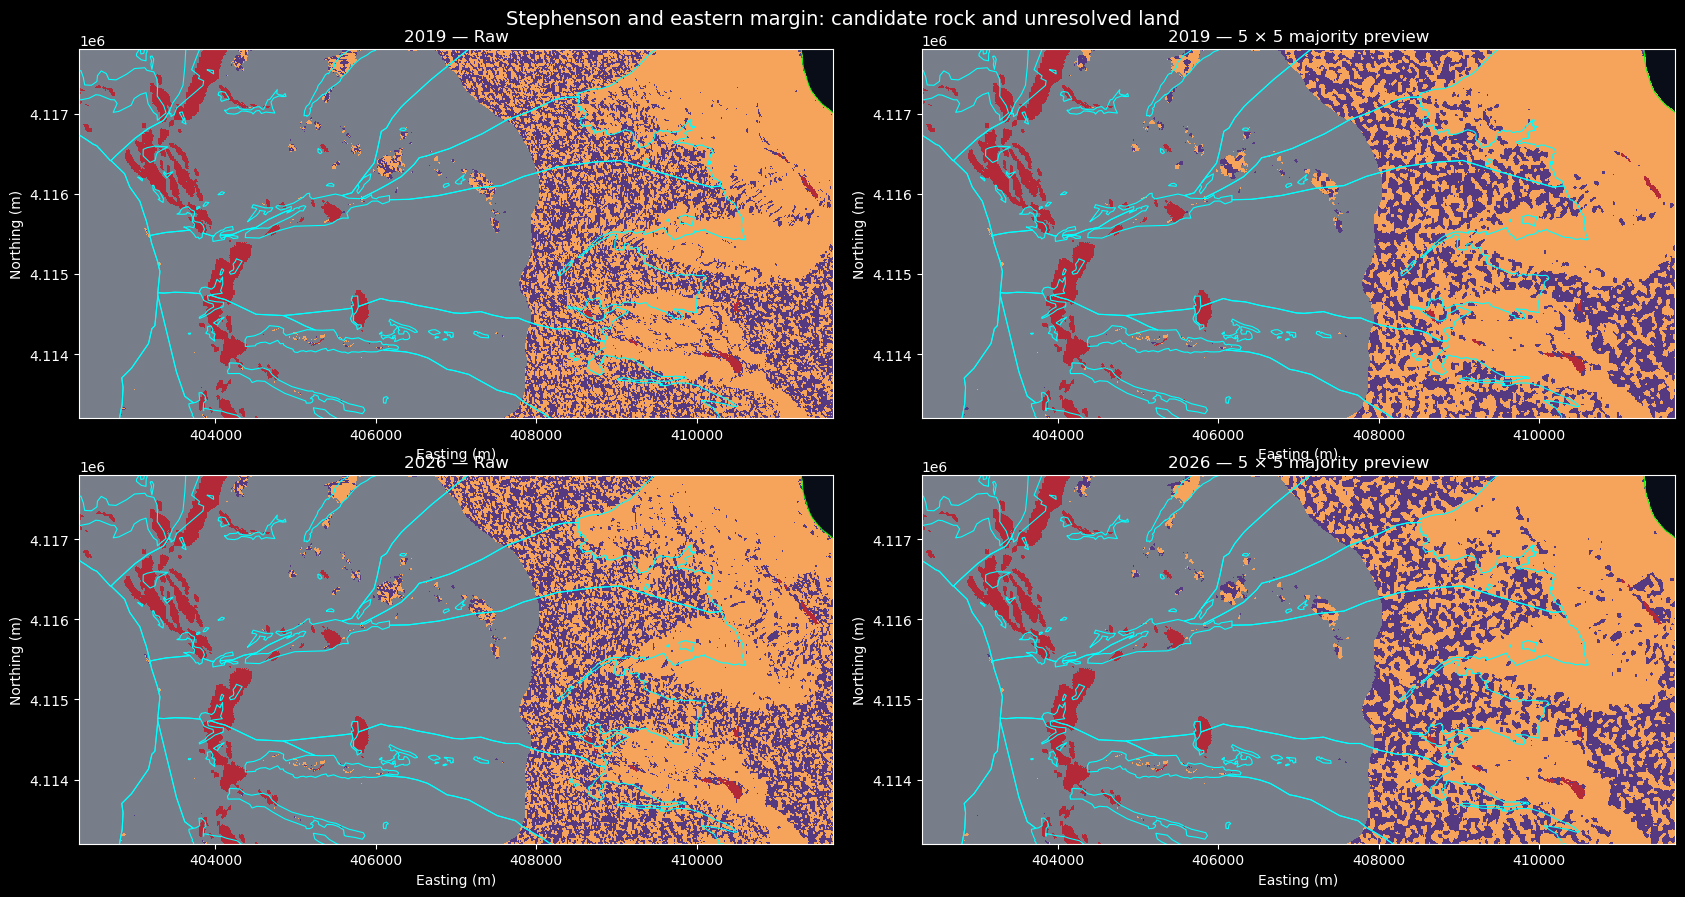

In [31]:
## Preview a 5 × 5 majority filter without saving changes ##

from scipy.ndimage import uniform_filter

focus = "Stephenson and eastern margin"
bounds = regions[focus]
filter_size = 5

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(2, 2, figsize = (17, 9))

    for row, year in enumerate((2019, 2026)):
        with rasterio.open(output_paths[year]) as source:
            window = source.window(*bounds).round_offsets().round_lengths()
            classes = source.read(1, window = window)
            left, bottom, right, top = source.window_bounds(window)

        # Count candidate-rock and evaluated-lowland pixels in each
        # neighbourhood. Other classes do not vote.
        lowland = (classes == 1) | (classes == 2)
        rock_votes = uniform_filter(
            (classes == 2).astype("float32"),
            size = filter_size,
            mode = "constant",
            cval = 0)
        lowland_votes = uniform_filter(
            lowland.astype("float32"),
            size = filter_size,
            mode = "constant",
            cval = 0)

        rock_share = np.divide(
            rock_votes,
            lowland_votes,
            out = np.zeros_like(rock_votes),
            where = lowland_votes > 0)

        filtered = classes.copy()
        filtered[lowland & (rock_share > 0.5)] = 2
        filtered[lowland & (rock_share < 0.5)] = 1

        changed = np.count_nonzero((filtered != classes) & lowland)
        evaluated = np.count_nonzero(lowland)
        print(f"{year}: {changed / evaluated:.1%} of evaluated pixels changed in this view")

        for col, (label, image) in enumerate(
                (("Raw", classes), ("5 × 5 majority preview", filtered))):
            ax = axes[row, col]
            ax.imshow(
                image,
                extent = (left, right, bottom, top),
                origin = "upper",
                cmap = colourmap,
                norm = colour_norm,
                interpolation = "nearest")

            coast.boundary.plot(ax = ax, color = "lime", linewidth = 0.7)
            glaciers_2014.boundary.plot(ax = ax, color = "cyan", linewidth = 0.8)

            ax.set_xlim(left, right)
            ax.set_ylim(bottom, top)
            ax.set_title(f"{year} — {label}")
            ax.set_xlabel("Easting (m)")
            ax.set_ylabel("Northing (m)")

    fig.suptitle(f"{focus}: candidate rock and unresolved land", fontsize = 14)
    fig.tight_layout()
    plt.show()

In [32]:
## Set paths and starting parameters ##

# Starting settings, not validated thresholds or an accuracy claim.
smooth_sigma_m = 30.0
ice_seed_max = 0.22
rock_seed_min = 0.45
seed_inset_m = 200.0
minimum_seed_area_m2 = 1000.0
minimum_polygon_area_m2 = 1000.0

radar_paths = {
    2019: Path("data/processed/S1A_IW_HH_2019-04-13_RTC_10m.tif"),
    2026: Path("data/processed/S1A_IW_HH_2026-04-12_RTC_10m.tif")}
coherence_paths = {
    year: Path(f"data/raw/coherence/Heard_coherence_{year}.tif")
    for year in radar_paths}
glacier_path = Path("Input_Data/heard_island_shp/Glacier_2014.shp")
coast_path = Path("Input_Data/HIMI_Features/himi_coastline_py.gpkg")
output_dir = Path("data/processed/coherence_watershed_v1")
output_dir.mkdir(parents = True, exist_ok = True)

required = [glacier_path, coast_path, *radar_paths.values(),
            *coherence_paths.values()]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run from the existing project folder. Missing: " + "; ".join(missing))

with rasterio.open(radar_paths[2019]) as reference:
    map_crs = reference.crs
    transform = reference.transform
    height, width = reference.height, reference.width
    x_res, y_res = reference.res
    bounds = reference.bounds
    grid = (map_crs, transform, height, width)

if map_crs is None or map_crs.to_epsg() != 32743:
    raise ValueError("Expected the existing EPSG:32743 metre-based SAR grid")

coast = gpd.read_file(coast_path).to_crs(map_crs)
glaciers = gpd.read_file(glacier_path).to_crs(map_crs)


In [33]:
## Prepare land and glacier-interior masks ##

def polygon_mask(frame):
    # Rasterise valid polygons on the existing SAR grid.
    geometries = frame.geometry.make_valid()
    geometries = geometries[
        geometries.notna() & ~geometries.is_empty]
    return rasterize(
        ((geometry, 1) for geometry in geometries),
        out_shape = (height, width), transform = transform,
        fill = 0, dtype = "uint8").astype(bool)

land = polygon_mask(coast)
old_ice = polygon_mask(glaciers)
# Erode the combined ice footprint, not each glacier's internal divide.
old_interior = ndi.distance_transform_edt(
    old_ice, sampling = (y_res, x_res)) >= seed_inset_m
pixel_area = x_res * y_res
minimum_seed_pixels = max(1, int(np.ceil(
    minimum_seed_area_m2 / pixel_area)))
minimum_polygon_pixels = max(1, int(np.ceil(
    minimum_polygon_area_m2 / pixel_area)))

def retain_components(mask, minimum_pixels):
    # Remove isolated patches smaller than the chosen mapping unit.
    components, _ = ndi.label(mask)
    sizes = np.bincount(components.ravel())
    keep = sizes >= minimum_pixels
    keep[0] = False
    return keep[components]


In [45]:
## Define the elevation zone held unchanged from 2014 ##

high_elevation_lock_m = 1000

# Locate the DEM already used in this project.
dem_matches = sorted(Path("Input_Data").rglob("HI_dem2019.tif"))
dem_matches += sorted(Path("Data/Spatial").glob("HI_dem2019.tif"))

if not dem_matches:
    raise FileNotFoundError("Could not find HI_dem2019.tif")

dem_path = dem_matches[0]

# Align the DEM with the existing SAR processing grid.
with rasterio.open(dem_path) as dem_source:
    with WarpedVRT(
        dem_source,
        crs = map_crs,
        transform = transform,
        width = width,
        height = height,
        resampling = Resampling.bilinear) as aligned_dem:

        lock_elevation = aligned_dem.read(
            1, masked = True).astype("float32").filled(np.nan)

high_elevation = (
    np.isfinite(lock_elevation)
    & (lock_elevation > high_elevation_lock_m))

print(f"2014 ice extent will be retained above {high_elevation_lock_m} m.")

2014 ice extent will be retained above 1000 m.


In [46]:
## Trace coherence boundaries with seeded watershed ##

def segment_coherence(coherence, valid, interior):
    # Return a candidate mask, seed map and smoothed coherence.
    # Normalised smoothing prevents NoData and the sea lowering land values.
    sigma = (smooth_sigma_m / y_res, smooth_sigma_m / x_res)
    weights = ndi.gaussian_filter(
        valid.astype("float32"), sigma = sigma)
    weighted = ndi.gaussian_filter(
        np.where(valid, coherence, 0).astype("float32"), sigma = sigma)
    smooth = np.divide(
        weighted, weights, out = np.zeros_like(weighted),
        where = weights > 1e-6)

    # Thresholds select seed interiors. They do not set the final border.
    ice_seeds = retain_components(
        valid & interior & (smooth <= ice_seed_max), minimum_seed_pixels)
    rock_seeds = retain_components(
        valid & (smooth >= rock_seed_min), minimum_seed_pixels)
        # Treat mapped high-elevation ice as ice seeds, regardless of coherence.
    ice_seeds |= valid & high_elevation & old_ice
    rock_seeds &= ~(high_elevation & old_ice)
    if not ice_seeds.any() or not rock_seeds.any():
        raise ValueError(
            "Both ice and stable-terrain seeds are required. "
            "These starting seed thresholds do not fit this scene.")

    markers = np.zeros(coherence.shape, dtype = "int32")
    markers[ice_seeds] = 1
    markers[rock_seeds] = 2

    # Do not call an isolated unseeded area ice by elimination.
    components, count = ndi.label(valid)
    has_ice = np.zeros(count + 1, dtype = bool)
    has_rock = np.zeros(count + 1, dtype = bool)
    has_ice[np.unique(components[ice_seeds])] = True
    has_rock[np.unique(components[rock_seeds])] = True
    usable = has_ice & has_rock
    usable[0] = False
    domain = valid & usable[components]
    markers[~domain] = 0

    # Bright gradient ridges are the barriers between growing regions.
    gradient = sobel(smooth, mask = valid).astype("float32")
    regions = watershed(
        gradient, markers = markers, mask = domain, connectivity = 1)
    # Restrict candidate ice to the combined 2014 footprint.
    ice = retain_components(
        (regions == 1) & old_ice, minimum_polygon_pixels)
    
    # Restore the 2014 footprint above the cutoff, including radar gaps.
    # Existing rock holes and the coastline/lagoon exclusions remain.
    ice[high_elevation] = (old_ice & land)[high_elevation]

    # 0 = outside coastline; 1 = candidate ice; 2 = candidate stable terrain;
    # 3 = unresolved land (also includes missing/shadowed observations).
    classes = np.zeros(coherence.shape, dtype = "uint8")
    classes[land] = 3
    classes[regions == 2] = 2
    classes[ice] = 1
    return classes, markers.astype("uint8"), smooth


In [47]:
## Exclude the updated 2014 lagoons ##

lagoon_path = Path(
    "Input_Data/heard_island_shp/UpdatedHI_Lagoons2014.shp")

lagoons = gpd.read_file(lagoon_path).to_crs(map_crs)
lagoon_mask = polygon_mask(lagoons)

# Rebuild the processing mask from the coastline, excluding mapped water.
coast_land = polygon_mask(coast)
land = coast_land & ~lagoon_mask

# Save this version separately from the original candidate outlines.
output_dir = Path("data/processed/coherence_watershed_v5_1000m_lock")
output_dir.mkdir(parents = True, exist_ok = True)

excluded_area = np.count_nonzero(
    coast_land & lagoon_mask) * pixel_area / 1_000_000

print(f"Mapped lagoon area excluded: {excluded_area:.3f} km²")

Mapped lagoon area excluded: 16.808 km²


2019: reading existing rasters and tracing boundaries...


C:\Users\harry\AppData\Local\Temp\ipykernel_14664\2082438363.py:34: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data_valid = radar.read(3) > 0.5
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\2082438363.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  shadow = radar.read(2) > 0.5


Saved data\processed\coherence_watershed_v5_1000m_lock\Heard_ice_candidate_2019.shp | 24 polygons | 6.5% of mapped land unresolved
2026: reading existing rasters and tracing boundaries...


C:\Users\harry\AppData\Local\Temp\ipykernel_14664\2082438363.py:34: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data_valid = radar.read(3) > 0.5
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\2082438363.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  shadow = radar.read(2) > 0.5


Saved data\processed\coherence_watershed_v5_1000m_lock\Heard_ice_candidate_2026.shp | 19 polygons | 6.2% of mapped land unresolved


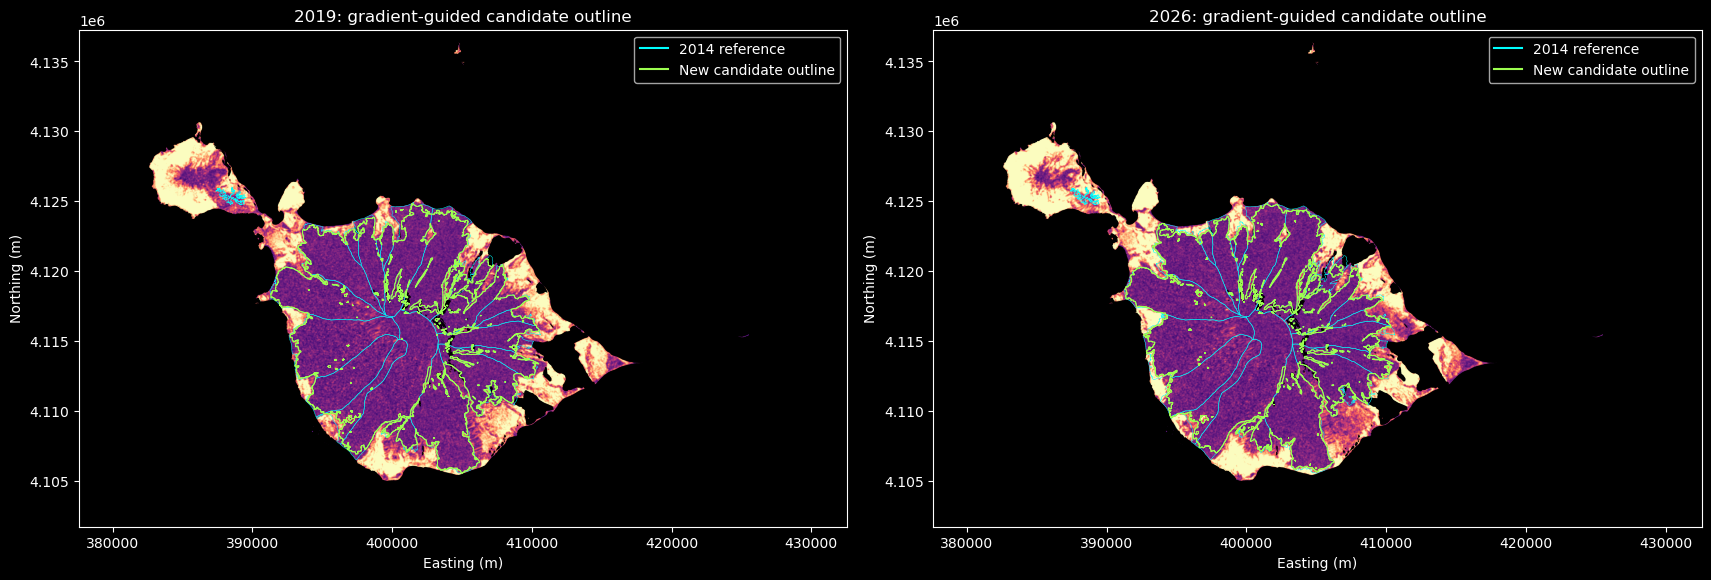

Done. Open both shapefiles and the assessment rasters in QGIS.


In [48]:
## Generate and export 2019 and 2026 candidate outlines ##

settings = {
    "method": "Gaussian smoothing, Sobel gradient, marker watershed",
    "status": "candidate; imagery review required",
    "smooth_sigma_m": smooth_sigma_m,
    "ice_seed_max": ice_seed_max,
    "rock_seed_min": rock_seed_min,
    "seed_inset_m": seed_inset_m,
    "minimum_seed_area_m2": minimum_seed_area_m2,
    "minimum_polygon_area_m2": minimum_polygon_area_m2,
    "crs": str(map_crs),
    "extent_constraint": "within_2014_footprint",
    "high_elevation_lock_m": high_elevation_lock_m,
    "high_elevation_reference": "2014 ice footprint",
    "dem_path": str(dem_path),
    "radar_paths": {str(k): str(v) for k, v in radar_paths.items()},
    "coherence_paths": {str(k): str(v) for k, v in coherence_paths.items()},
    "outline_path": str(glacier_path), "coastline_path": str(coast_path), "lagoon_path": str(lagoon_path)}
(output_dir / "settings.json").write_text(
    json.dumps(settings, indent = 2), encoding = "utf-8")

extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
with plt.style.context("dark_background"):
    fig, axes = plt.subplots(
        1, 2, figsize = (17, 8), layout = "constrained")

    for ax, year in zip(axes, radar_paths):
        print(f"{year}: reading existing rasters and tracing boundaries...",
              flush = True)
        with rasterio.open(radar_paths[year]) as radar:
            if (radar.crs, radar.transform, radar.height, radar.width) != grid:
                raise ValueError(f"{year}: SAR grids differ")
            data_valid = radar.read(3) > 0.5
            shadow = radar.read(2) > 0.5
        with rasterio.open(coherence_paths[year]) as source:
            with WarpedVRT(
                source, crs = map_crs, transform = transform,
                width = width, height = height,
                resampling = Resampling.bilinear) as aligned:
                coherence = aligned.read(
                    1, masked = True).astype("float32").filled(np.nan)

        valid = (land & data_valid & ~shadow & np.isfinite(coherence)
                 & (coherence >= 0) & (coherence <= 1))
        classes, markers, smooth = segment_coherence(
            coherence, valid, old_interior)

        raster_path = output_dir / f"Heard_watershed_{year}.tif"
        with rasterio.open(
            raster_path, "w", driver = "GTiff", width = width,
            height = height, count = 2, dtype = "uint8", crs = map_crs,
            transform = transform, compress = "deflate", tiled = True) as dst:
            dst.write(classes, 1)
            dst.write(markers, 2)
            dst.set_band_description(
                1, "0 outside coast or mapped lagoon; 1 candidate ice; 2 stable terrain; 3 unresolved")
            dst.set_band_description(
                2, "Watershed seeds: 0 none; 1 ice; 2 stable terrain")
            dst.update_tags(status = "DRAFT", method = settings["method"])

        # Polygonise regions, preserving holes and the original grid's CRS.
        records = [
            {"year": year, "status": "candidate",
             "geometry": shapely_shape(geometry)}
            for geometry, value in shapes(
                classes, mask = classes == 1, transform = transform,
                connectivity = 4) if value == 1]
        if not records:
            raise ValueError(f"{year}: no candidate ice polygons were produced")
        outlines = gpd.GeoDataFrame(records, crs = map_crs)
                # Clip edge pixels precisely to the original vector boundary.
        footprint_2014 = glaciers.geometry.make_valid().union_all()
        outlines = gpd.clip(
            outlines, footprint_2014, keep_geom_type = True)
        shp_path = output_dir / f"Heard_ice_candidate_{year}.shp"
        outlines.to_file(shp_path, driver = "ESRI Shapefile", index = False)

        ax.imshow(
            np.ma.masked_where(~valid, smooth), extent = extent,
            origin = "upper", cmap = "magma", vmin = 0, vmax = 0.8)
        glaciers.boundary.plot(ax = ax, color = "cyan", linewidth = 0.35)
        outlines.boundary.plot(ax = ax, color = "#9dff50", linewidth = 0.75)
        ax.plot([], [], color = "cyan", label = "2014 reference")
        ax.plot([], [], color = "#9dff50", label = "New candidate outline")
        ax.set(xlim = (bounds.left, bounds.right),
               ylim = (bounds.bottom, bounds.top),
               title = f"{year}: gradient-guided candidate outline",
               xlabel = "Easting (m)", ylabel = "Northing (m)")
        ax.legend(loc = "upper right")
        unresolved = np.count_nonzero(classes == 3) / np.count_nonzero(land)
        print(f"Saved {shp_path} | {len(outlines)} polygons | "
              f"{unresolved:.1%} of mapped land unresolved", flush = True)
        del coherence, classes, markers, smooth, valid

    plt.show()

print("Done. Open both shapefiles and the assessment rasters in QGIS.")


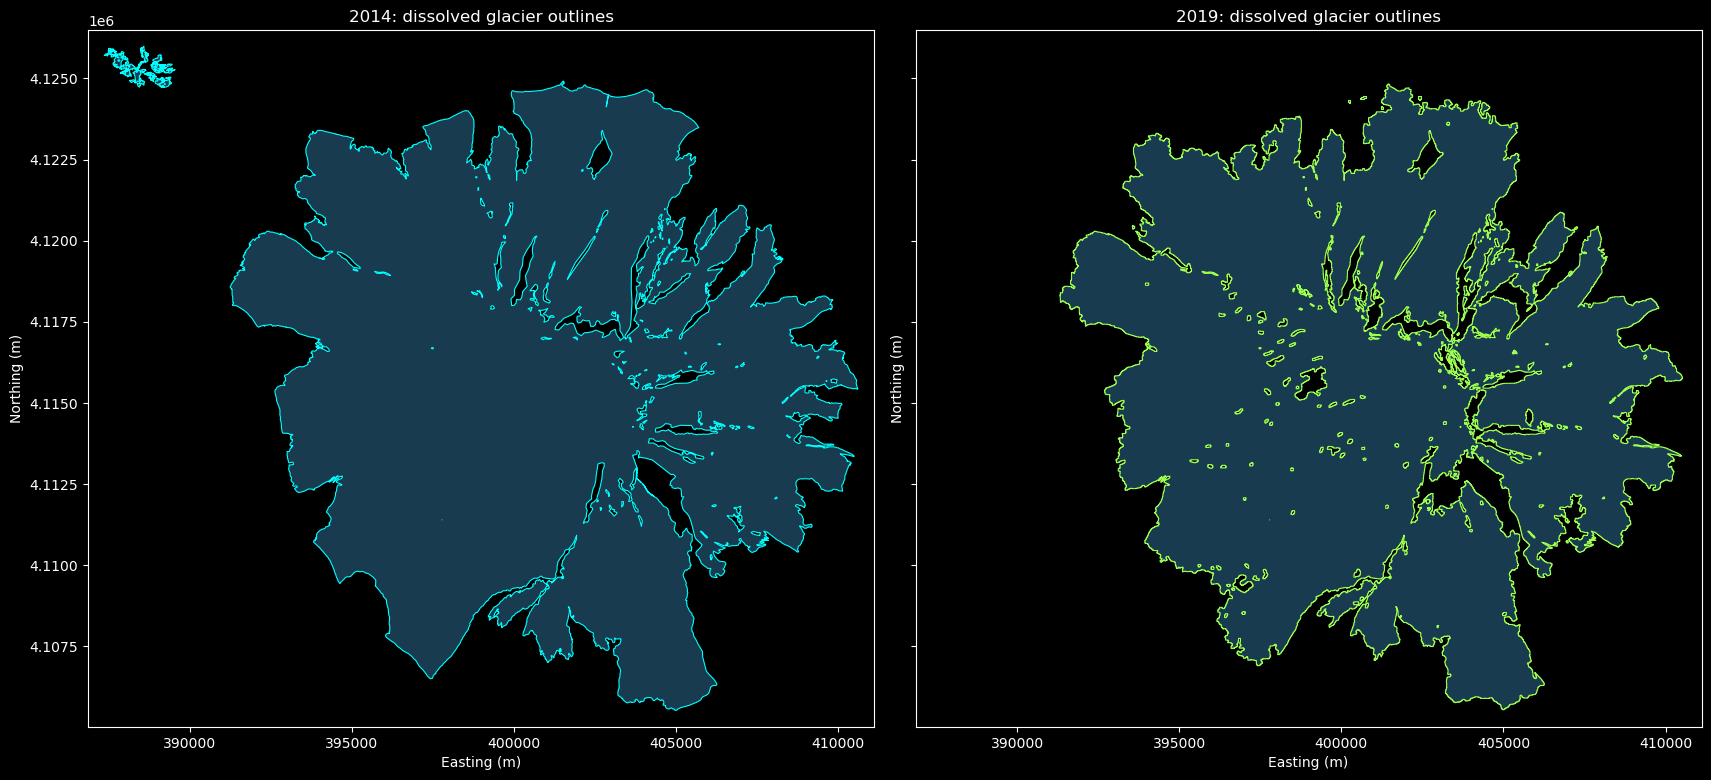

In [42]:
## Compare dissolved 2014 and 2019 glacier outlines ##

preview_2014 = glaciers[["geometry"]].copy()

preview_2019 = gpd.read_file(
    output_dir / "Heard_ice_candidate_2019.shp"
).to_crs(preview_2014.crs)

# Dissolve each year while retaining internal holes.
preview_2014["geometry"] = preview_2014.geometry.make_valid()
preview_2019["geometry"] = preview_2019.geometry.make_valid()

preview_2014 = preview_2014.dissolve()
preview_2019 = preview_2019[["geometry"]].dissolve()

# Use the 2014 footprint to set identical map extents.
preview_left, preview_bottom, preview_right, preview_top = (
    preview_2014.total_bounds)

preview_margin = 500

with plt.style.context("dark_background"):
    preview_fig, preview_axes = plt.subplots(
        1, 2, figsize = (17, 9),
        sharex = True, sharey = True,
        layout = "constrained")

    for ax, layer, year, colour in zip(
        preview_axes,
        (preview_2014, preview_2019),
        (2014, 2019),
        ("cyan", "#9DFF50")):

        # Blue fill shows ice; enclosed black areas remain holes.
        layer.plot(
            ax = ax,
            facecolor = "#183B50",
            edgecolor = colour,
            linewidth = 0.8)

        ax.set(
            title = f"{year}: dissolved glacier outlines",
            xlabel = "Easting (m)",
            ylabel = "Northing (m)",
            xlim = (
                preview_left - preview_margin,
                preview_right + preview_margin),
            ylim = (
                preview_bottom - preview_margin,
                preview_top + preview_margin))

        ax.set_aspect("equal")

    plt.show()

Saved the locked 2019 reference.


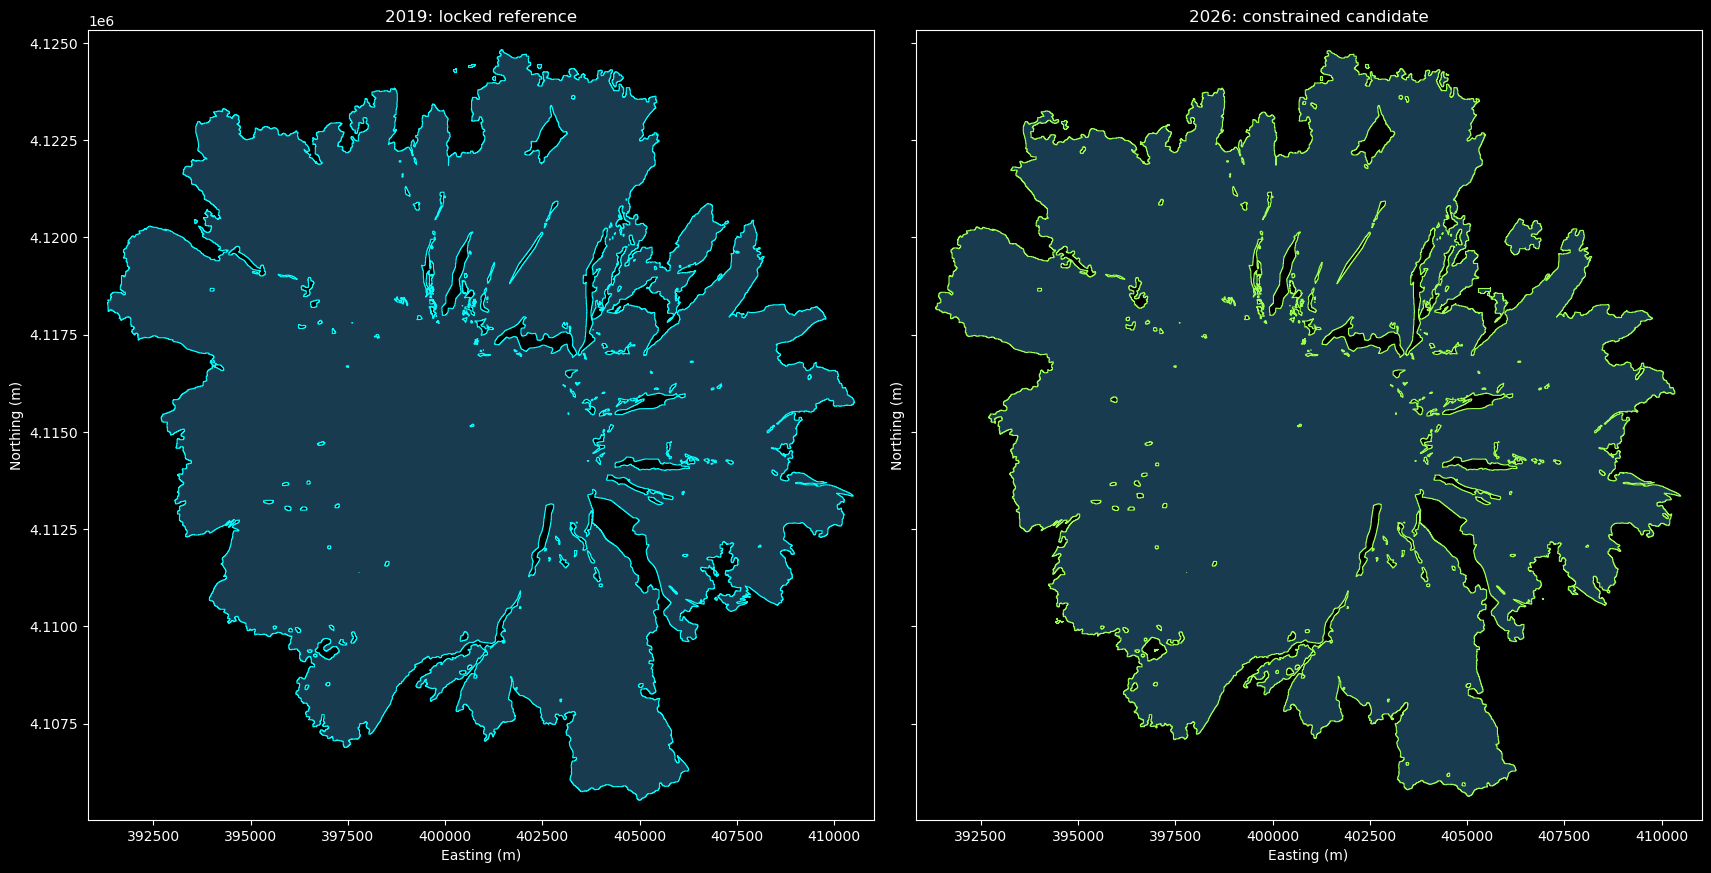

2019 reference: data\processed\coherence_watershed_v6_1000m_lock\Heard_ice_2019_reference.gpkg
2026 candidate: data\processed\coherence_watershed_v6_1000m_lock\Heard_ice_2026_within_2019.gpkg


In [49]:
## Lock the 2019 reference and constrain the 2026 candidate ##

source_dir = Path("data/processed/coherence_watershed_v5_1000m_lock")

locked_dir = Path("data/processed/coherence_watershed_v6_1000m_lock")

locked_dir.mkdir(parents = True, exist_ok = True)

reference_path = locked_dir / "Heard_ice_2019_reference.gpkg"
candidate_path = locked_dir / "Heard_ice_2026_within_2019.gpkg"

# Reuse the saved reference so reruns cannot silently replace it.
if reference_path.exists():
    reference_2019 = gpd.read_file(reference_path, layer = "ice_2019")
    print("Reusing the locked 2019 reference.")

else:
    reference_2019 = gpd.read_file(
        source_dir / "Heard_ice_candidate_2019.shp")

    reference_2019["geometry"] = (
        reference_2019.geometry.make_valid())

    reference_2019 = reference_2019[["geometry"]].dissolve()
    reference_2019["year"] = 2019
    reference_2019["use_scope"] = "Brown and Stephenson"
    reference_2019["status"] = "Accepted for study glaciers"

    reference_2019.to_file(
        reference_path, layer = "ice_2019",
        driver = "GPKG", index = False)

    print("Saved the locked 2019 reference.")

# Intersect the existing 2026 candidate with the complete 2019 geometry.
candidate_2026 = gpd.read_file(
    source_dir / "Heard_ice_candidate_2026.shp")

candidate_2026 = candidate_2026.to_crs(reference_2019.crs)
candidate_2026["geometry"] = candidate_2026.geometry.make_valid()

constrained_2026 = gpd.clip(
    candidate_2026, reference_2019, keep_geom_type = True)

constrained_2026["constraint"] = "Within 2019 ice footprint"
constrained_2026["status"] = "Candidate"

constrained_2026.to_file(
    candidate_path, layer = "ice_2026",
    driver = "GPKG", index = False)

# Compare both years at the same scale, retaining internal holes.
comparison_2026 = constrained_2026[["geometry"]].dissolve()
plot_left, plot_bottom, plot_right, plot_top = reference_2019.total_bounds
plot_margin = 500

with plt.style.context("dark_background"):
    comparison_fig, comparison_axes = plt.subplots(
        1, 2, figsize = (17, 9),
        sharex = True, sharey = True,
        layout = "constrained")

    for ax, layer, title, colour in zip(
        comparison_axes,
        (reference_2019, comparison_2026),
        ("2019: locked reference", "2026: constrained candidate"),
        ("cyan", "#9DFF50")):

        layer.plot(
            ax = ax,
            facecolor = "#183B50",
            edgecolor = colour,
            linewidth = 0.8)

        ax.set(
            title = title,
            xlabel = "Easting (m)",
            ylabel = "Northing (m)",
            xlim = (
                plot_left - plot_margin,
                plot_right + plot_margin),
            ylim = (
                plot_bottom - plot_margin,
                plot_top + plot_margin))

        ax.set_aspect("equal")

    plt.show()

print(f"2019 reference: {reference_path}")
print(f"2026 candidate: {candidate_path}")

In [51]:
## Finalise and save the accepted 2019 and 2026 outlines ##

source_dir = Path("data/processed/coherence_watershed_v6_1000m_lock")
final_dir = Path("data/processed/glacier_outlines_final")

source_files = {
    2019: "Heard_ice_2019_reference.gpkg",
    2026: "Heard_ice_2026_within_2019.gpkg"}

if final_dir.exists():
    # Reuse the frozen outputs when the notebook is run again.
    print("Final outlines already exist. Reusing the saved copies.")

else:
    # Read the accepted outlines, including the final 2026 constraint.
    accepted_outlines = {
        year: gpd.read_file(source_dir / filename, layer = f"ice_{year}")
        for year, filename in source_files.items()}

    # Check that both inputs contain valid polygons on the expected grid CRS.
    for year, frame in accepted_outlines.items():
        if frame.crs is None or frame.crs.to_epsg() != 32743:
            raise ValueError(f"{year}: expected EPSG:32743.")

        if (
            frame.empty
            or frame.geometry.isna().any()
            or frame.geometry.is_empty.any()
            or not frame.geometry.is_valid.all()
            or not frame.geom_type.isin(["Polygon", "MultiPolygon"]).all()):
            raise ValueError(f"{year}: missing or invalid outline geometry.")

    # Confirm that 2026 remains within 2019, allowing numerical slivers only.
    footprint_2019 = accepted_outlines[2019].geometry.union_all()
    footprint_2026 = accepted_outlines[2026].geometry.union_all()
    outside_area = footprint_2026.difference(footprint_2019).area

    if outside_area > 1.0:
        raise ValueError(
            f"2026 extends outside 2019 by {outside_area:.2f} m². "
            "Rerun the cell that constrains 2026 to the 2019 reference.")

    # Record the assumptions alongside the final vector files.
    metadata = {
        "saved_utc": datetime.now(timezone.utc).isoformat(),
        "comparison_years": [1947, 1988, 2014, 2019, 2026],
        "accepted_study_glaciers": ["Brown", "Stephenson"],
        "source_files": {
            str(year): str(source_dir / filename)
            for year, filename in source_files.items()},
        "method": "HH coherence gradient with marker-controlled watershed",
        "extent_constraints": {
            "2019": "Within the 2014 ice footprint",
            "2026": "Within the accepted 2019 ice footprint"},
        "high_elevation_rule": (
            "Above 1000 m, retain the 2014 ice footprint in both years, "
            "subject to coastline and lagoon exclusions."),
        "lagoon_exclusion": "UpdatedHI_Lagoons2014.shp",
        "interpretation": (
            "No advance and no change above 1000 m are imposed assumptions. "
            "Acceptance concerns Brown and Stephenson; other glaciers retain "
            "known mapping issues and have not been accepted for analysis.")}

    # Preserve the saved segmentation settings where available.
    settings_path = Path(
        "data/processed/coherence_watershed_v5_1000m_lock/settings.json")

    if settings_path.exists():
        metadata["segmentation_settings"] = json.loads(
            settings_path.read_text(encoding = "utf-8"))

    # Complete both exports before creating the final output folder.
    final_dir.parent.mkdir(parents = True, exist_ok = True)

    with TemporaryDirectory(dir = final_dir.parent) as temporary_dir:
        staging_dir = Path(temporary_dir) / final_dir.name
        staging_dir.mkdir()

        for year, frame in accepted_outlines.items():
            # Keep the geometry unchanged and replace draft attributes.
            final_outline = frame[["geometry"]].copy()
            final_outline["year"] = year
            final_outline["status"] = "accepted"
            final_outline["scope"] = "Brown and Stephenson"
            final_outline["lock_m"] = 1000

            final_outline.to_file(
                staging_dir / f"Heard_ice_{year}_final.gpkg",
                layer = f"ice_{year}", driver = "GPKG", index = False)

            final_outline.to_file(
                staging_dir / f"Heard_ice_{year}_final.shp",
                driver = "ESRI Shapefile", index = False)

        (staging_dir / "outline_metadata.json").write_text(
            json.dumps(metadata, indent = 2), encoding = "utf-8")

        staging_dir.rename(final_dir)

    print("Both years finalised and saved.")

# Load the frozen GeoPackages for subsequent analysis.
final_2019 = gpd.read_file(
    final_dir / "Heard_ice_2019_final.gpkg", layer = "ice_2019")

final_2026 = gpd.read_file(
    final_dir / "Heard_ice_2026_final.gpkg", layer = "ice_2026")

print(f"Final outlines: {final_dir.resolve()}")

Both years finalised and saved.
Final outlines: C:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\data\processed\glacier_outlines_final
